In [1]:
import sys, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import glob
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from tqdm.notebook import tqdm

tqdm.pandas()

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [6]:
DATA_PATH=f"{cfg.DATA_PATH}crimebb/"
CSV_PATH = f"{DATA_PATH}/{cfg.YEAR}/csv/"
CSV_PROCESSED = f"{CSV_PATH}/processed_from_csv/"

### Exploring data

#### members

In [7]:
members_df = pd.read_csv(f"{CSV_PROCESSED}members.csv", sep="\\", low_memory=False)
members_df

,user_id,username,site_id
0,26662,itsmeItsme,3
1,19605,ozgursevgi,3
2,19809,michaelharry,3
3,21273,MyMind,3
4,18951,jpike10,3
...,...,...,...
1308471,4445538,chrischmi,0
1308472,4444135,MORKID,0
1308473,4439866,Juandiego Benitez,0
1308474,4387328,Akash dixit,0


#### websites

In [8]:
website_df = pd.read_csv(f"{CSV_PROCESSED}sites.csv", sep="\\", low_memory=False)
website_df

,site_id,site_name
0,0,hackforums.net
1,1,www.kernelmode.info/forum
2,2,thehub7xbw4dc5r2.onion/
3,3,offensivecommunity.net/index.php
4,4,www.mpgh.net
5,5,stresserforums.net/index.php
6,6,greysec.net/index.php
7,7,garage4hackers.com/forum.php
8,10,forum.antichat.ru
9,12,www.raidforums.com


#### boards

In [9]:
boards_df = pd.read_csv(f"{CSV_PROCESSED}boards.csv", sep="\\", low_memory=False)
boards_df.drop_duplicates(inplace=True)
boards_df

,board_id,site_id,site_name,board_title,board_url
0,78,3,offensivecommunity.net/index.php,Rate My Graphic,http://offensivecommunity.net/forumdisplay.php...
1,51,3,offensivecommunity.net/index.php,Core Hacking,http://offensivecommunity.net/forumdisplay.php...
2,15,3,offensivecommunity.net/index.php,Group and Crew General Discussions,http://offensivecommunity.net/forumdisplay.php...
3,79,3,offensivecommunity.net/index.php,Exploits written in Ruby,http://offensivecommunity.net/forumdisplay.php...
4,73,3,offensivecommunity.net/index.php,Website Market,http://offensivecommunity.net/forumdisplay.php...
...,...,...,...,...,...
1946,133,0,hackforums.net,Rate My Graphic,https://hackforums.net/forumdisplay.php?fid=13...
1947,158,0,hackforums.net,Free Graphic Requests,https://hackforums.net/forumdisplay.php?fid=15...
1948,181,0,hackforums.net,Graphic Services,https://hackforums.net/forumdisplay.php?fid=18...
1949,69,0,hackforums.net,Graphic Tutorials,https://hackforums.net/forumdisplay.php?fid=69...


#### threads

In [10]:
threads_df = pd.read_csv(f"{CSV_PROCESSED}threads.csv", sep="\\", low_memory=False)
threads_df = threads_df[["thread_id", "site_id", "board_id", "user_id", "username", "thread_title"]].copy()
threads_df.drop_duplicates(inplace=True)
threads_df

,thread_id,site_id,board_id,user_id,username,thread_title
0,61028,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban..."
1,60999,3,12,33823,midomark2016,100% social hack successful
2,60987,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban..."
3,13207,3,12,1,Codefire,Advertisement Space
4,60947,3,12,34455,icceEhackers1234,experience quality hack from icefoghackers wit...
...,...,...,...,...,...,...
5264152,5808427,0,219,3683116,L0-kae,I'm looking to buy a custom avatar.
5264153,5808056,0,219,1704557,xf0xalz,Curriculum Model
5264154,5807686,0,219,3836526,Blake8598,Web Developer/Graphic Designer for hire
5264155,5806810,0,219,2737304,Tr0janVirus,Album Cover


#### Posts

In [11]:
chunk_size = 1000000

posts_reader = pd.read_csv(f"{CSV_PROCESSED}posts.csv", sep="\\", low_memory=False, iterator=True)
            
posts_df = pd.DataFrame()

len_readed=chunk_size
while len_readed>=chunk_size:
    cur_posts_df = posts_reader.get_chunk(chunk_size).copy()
    len_readed = cur_posts_df.shape[0]
    cur_posts_df.drop_duplicates(inplace=True)

    # removing missing names
    cur_posts_df[ (cur_posts_df["username"].str.lower()!="none") ].drop_duplicates(inplace=True)
    cur_posts_df[ (~cur_posts_df["username"].isna()) ].drop_duplicates(inplace=True)
    cur_posts_df[ (cur_posts_df["username"].str.lower()!="nan") ].drop_duplicates(inplace=True)

    posts_df = pd.concat([posts_df, cur_posts_df], ignore_index=True)
    
    del cur_posts_df
    gc.collect()

In [12]:
posts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54443387 entries, 0 to 54443386
Data columns (total 9 columns):
 #   Column              Dtype
---  ------              -----
 0   post_id             int64
 1   site_id             int64
 2   board_id            int64
 3   thread_id           int64
 4   user_id             int64
 5   username            str  
 6   user_reputation     int64
 7   content             str  
 8   post_data_creation  str  
dtypes: int64(6), str(3)
memory usage: 17.3 GB


### Drawing Missing Values

#### user_id equals None

In [13]:
none_members_users = len(members_df[ (members_df["username"].str.lower()=="none") | (members_df["username"].isna()) | (members_df["username"].str.lower()=="nan") ].copy().drop_duplicates())

In [14]:
none_threads_users = len(threads_df[ (threads_df["username"].str.lower()=="none") | (threads_df["username"].isna()) | (threads_df["username"].str.lower()=="nan") ].copy().drop_duplicates())

In [15]:
none_posts_users = len(posts_df[ (posts_df["username"].str.lower()=="none") | (posts_df["username"].isna()) | (posts_df["username"].str.lower()=="nan") ].copy().drop_duplicates())

#### thread title None

In [16]:
posts_threads_df = pd.merge(posts_df, threads_df[["site_id", "board_id", "thread_id", "thread_title"]].drop_duplicates(), on=["site_id", "board_id", "thread_id"], how="left")

In [17]:
none_threads_title = len(threads_df[threads_df["thread_title"].isna()])

In [18]:
none_posts_threads_title = len(posts_threads_df[posts_threads_df["thread_title"].isna()])

#### posts content None

In [19]:
none_posts_content = len(posts_threads_df[posts_threads_df["content"].isna()])

#### Draw

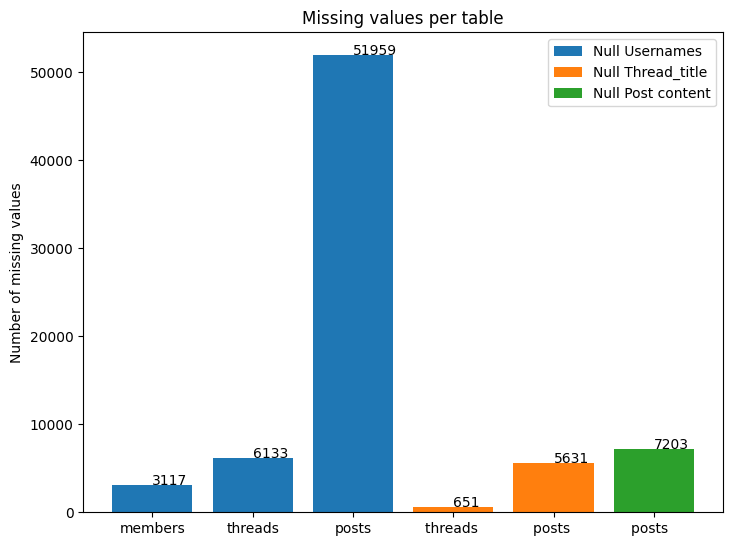

In [20]:
# None usernames

legends_users = ["members", "threads", "posts"]
values_users = [none_members_users, none_threads_users, none_posts_users]

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.bar(legends_users,values_users, label='Null Usernames')
for x,y,p in zip(legends_users, values_users, values_users):
  plt.text(x, y, p)

# None threads title

legends_threads = ["threads ", "posts "]
values_threads = [none_threads_title, none_posts_threads_title]

ax.bar(legends_threads, values_threads, label='Null Thread_title')
for x,y,p in zip(legends_threads, values_threads, values_threads):
  plt.text(x, y, p)

# None posts content

legends_posts = ["posts  "]
values_posts = [none_posts_content]

ax.bar(legends_posts, values_posts, label='Null Post content')
for x,y,p in zip(legends_posts, values_posts, values_posts):
  plt.text(x, y, p)

ax.legend()
ax.set_title("Missing values per table")
ax.set_ylabel("Number of missing values")
plt.show()

### Removing none values

#### Members

In [21]:
members_df = members_df[ (members_df["username"].str.lower()!="none")].copy().drop_duplicates()
members_df = members_df[ (~members_df["username"].isna()) ].copy().drop_duplicates()
members_df = members_df[ (members_df["username"].str.lower()!="nan") ].copy().drop_duplicates()

members_df

,user_id,username,site_id
0,26662,itsmeItsme,3
1,19605,ozgursevgi,3
2,19809,michaelharry,3
3,21273,MyMind,3
4,18951,jpike10,3
...,...,...,...
1308471,4445538,chrischmi,0
1308472,4444135,MORKID,0
1308473,4439866,Juandiego Benitez,0
1308474,4387328,Akash dixit,0


#### Threads

In [22]:
threads_df = threads_df[ (threads_df["username"].str.lower()!="none") ].copy().drop_duplicates()
threads_df = threads_df[ (~threads_df["username"].isna()) ].copy().drop_duplicates()
threads_df = threads_df[ (threads_df["username"].str.lower()!="nan") ].copy().drop_duplicates()

threads_df

,thread_id,site_id,board_id,user_id,username,thread_title
0,61028,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban..."
1,60999,3,12,33823,midomark2016,100% social hack successful
2,60987,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban..."
3,13207,3,12,1,Codefire,Advertisement Space
4,60947,3,12,34455,icceEhackers1234,experience quality hack from icefoghackers wit...
...,...,...,...,...,...,...
5264152,5808427,0,219,3683116,L0-kae,I'm looking to buy a custom avatar.
5264153,5808056,0,219,1704557,xf0xalz,Curriculum Model
5264154,5807686,0,219,3836526,Blake8598,Web Developer/Graphic Designer for hire
5264155,5806810,0,219,2737304,Tr0janVirus,Album Cover


### Members x Sites

In [23]:
member_website = pd.merge(members_df[["username", "site_id"]].drop_duplicates(),
                          boards_df[["site_id", "site_name"]].drop_duplicates(),
                          on="site_id", how="left").drop_duplicates()
member_website

,username,site_id,site_name
0,itsmeItsme,3,offensivecommunity.net/index.php
1,ozgursevgi,3,offensivecommunity.net/index.php
2,michaelharry,3,offensivecommunity.net/index.php
3,MyMind,3,offensivecommunity.net/index.php
4,jpike10,3,offensivecommunity.net/index.php
...,...,...,...
1301434,chrischmi,0,hackforums.net
1301435,MORKID,0,hackforums.net
1301436,Juandiego Benitez,0,hackforums.net
1301437,Akash dixit,0,hackforums.net


### Site x Member

In [24]:
site_users_df = pd.pivot_table(member_website,
                 index=["site_name"],
                 values=["username"],
                 aggfunc={
                     "username":len
                 }
                ).sort_values(by="username", ascending=False).reset_index(level=0)
site_users_df.set_index('site_name', inplace=True)
site_users_df.rename(columns={"username":"num_users"}, inplace=True)
site_users_df

,num_users
site_name,
hackforums.net,614947
www.mpgh.net,475942
forum.antichat.ru,77832
www.raidforums.com,44096
dreadditevelidot.onion/discover,35428
lwplxqzvmgu43uff.onion/index.php,17240
offensivecommunity.net/index.php,11508
thehub7xbw4dc5r2.onion/,8219
www.safeskyhacks.com/Forums/forum.php,7402


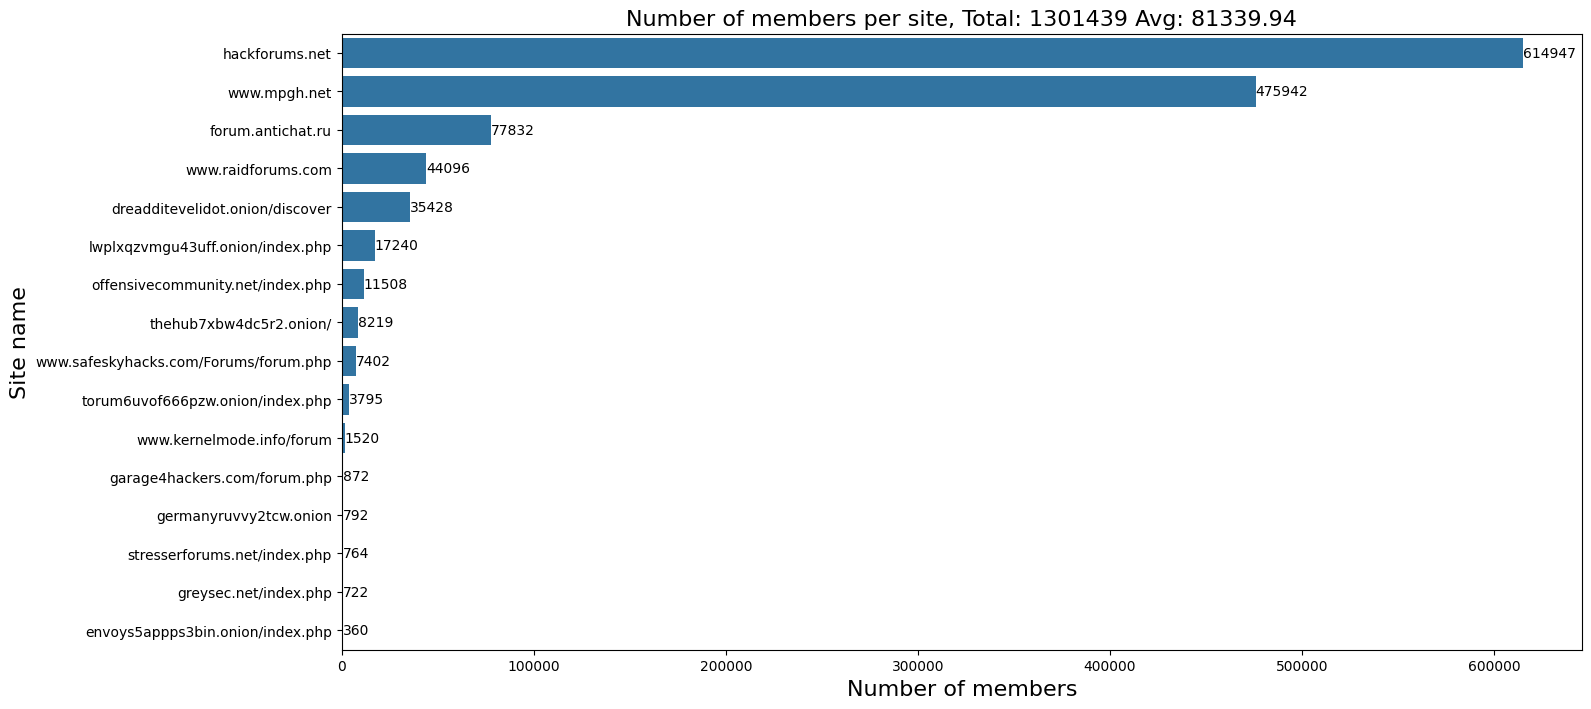

In [25]:
mean_val = round(site_users_df["num_users"].mean(), 2)
sum_val = round(site_users_df["num_users"].sum(), 2)

_, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1, sharex=False, sharey=False)

df = site_users_df.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax
           )

sns_fig.set_title(f"Number of members per site, Total: {sum_val} Avg: {mean_val}", fontsize=16)
sns_fig.set_ylabel(f"Site name", fontsize=16)
sns_fig.set_xlabel('Number of members', fontsize=16)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f')

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

Text(0, 0.5, 'Number of users')

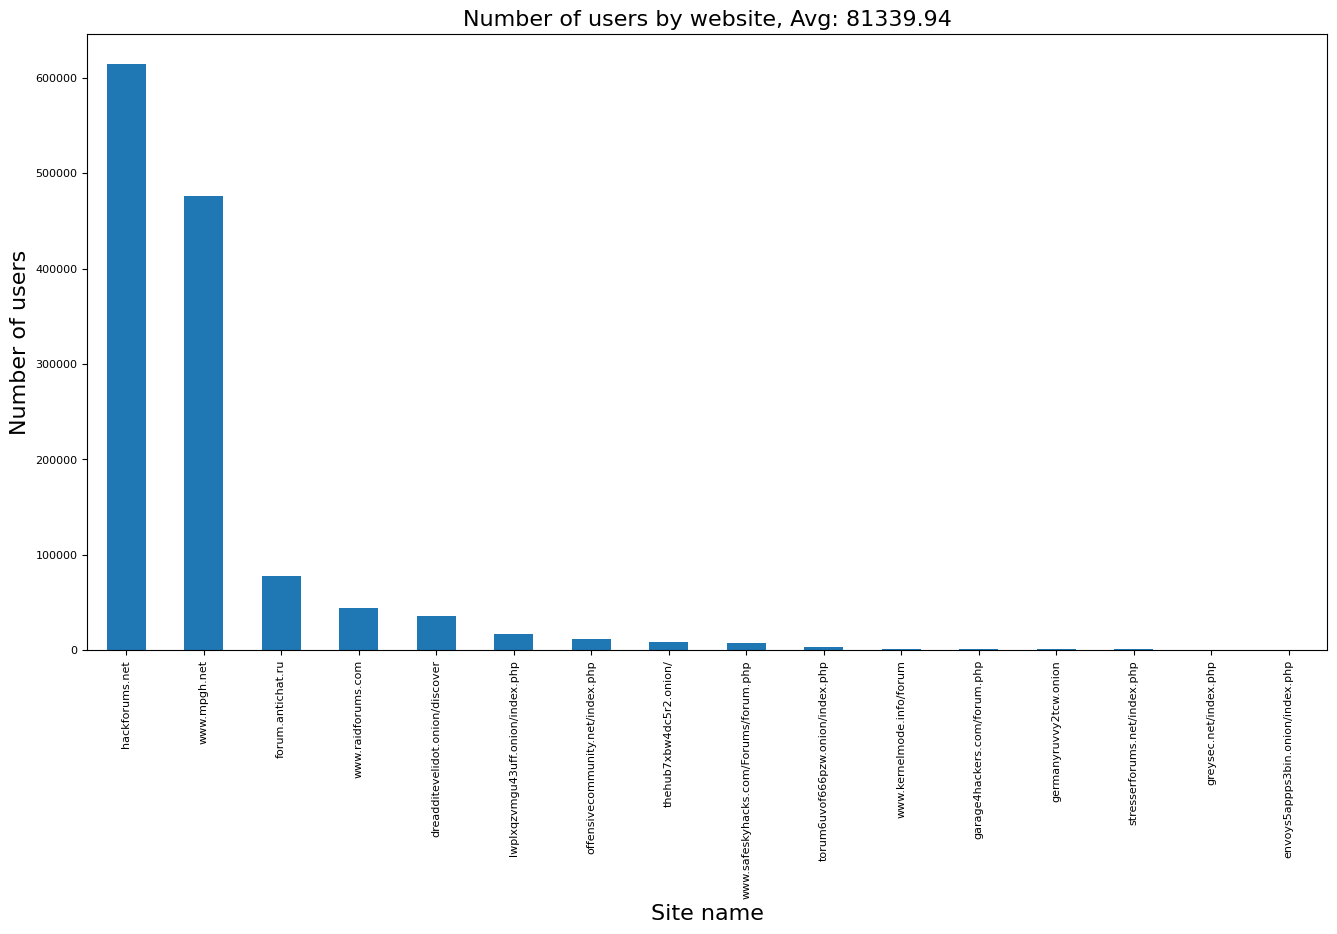

In [26]:
mean_val = round(site_users_df["num_users"].mean(), 2)

ax = site_users_df.plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

ax.get_legend().remove()
ax.set_title(f"Number of users by website, Avg: {mean_val}", fontsize=16)
ax.set_xlabel('Site name', fontsize=16)
ax.set_ylabel(f"Number of users", fontsize=16)

##### members x website

In [27]:
users_sites_df = pd.pivot_table(member_website,
                 index=["username"],
                 values=["site_name"],
                 aggfunc={
                     "site_name":len
                 }
                ).sort_values(by="site_name", ascending=False).reset_index(level=0)
users_sites_df.rename(columns={"site_name":"num_sites_interacted"}, inplace=True)
users_sites_df.set_index("username", inplace=True)
users_sites_df

,num_sites_interacted
username,
Tony,8
lol,7
Josh,6
Fox,6
Anon,6
...,...
Rooob,1
RoonyLD,1
Roonvar,1


In [28]:
users_sites_ = users_sites_df.pivot_table(columns=['num_sites_interacted'], aggfunc='size')
users_sites_

num_sites_interacted
1    1219509
2      36911
3       2220
4        270
5         61
6          8
7          1
8          1
dtype: int64

Text(0, 0.5, 'Number of users')

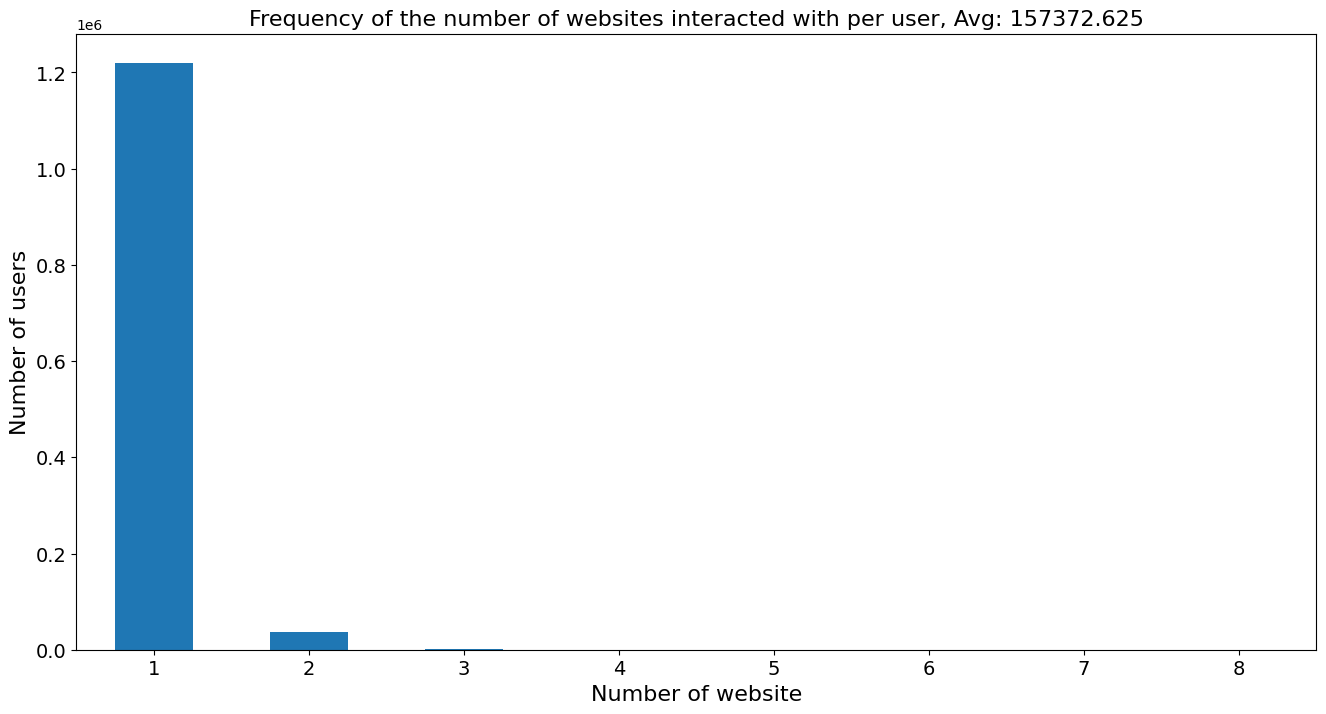

In [29]:
ax = users_sites_.plot(kind="bar", figsize=(16,8), rot=0, fontsize=14)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of websites interacted with per user, Avg: {users_sites_.mean()}", fontsize=16)
ax.set_xlabel('Number of website', fontsize=16)
ax.set_ylabel(f"Number of users", fontsize=16)

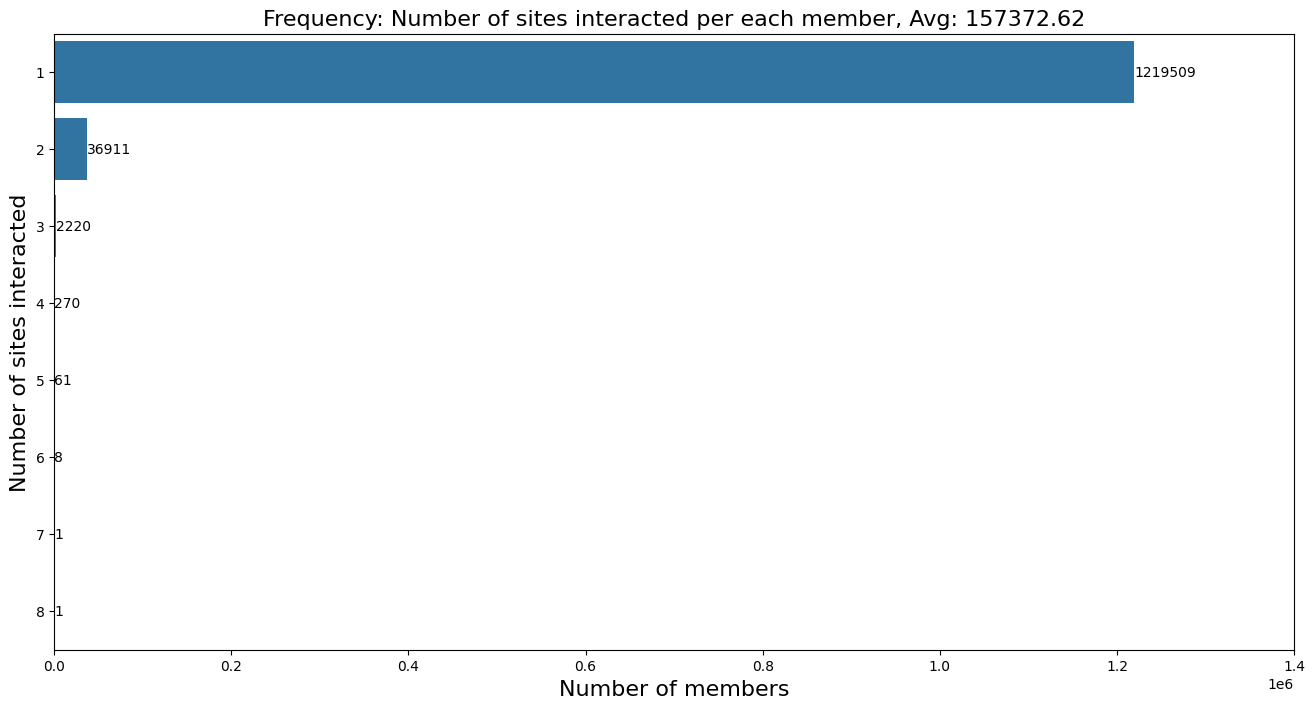

In [30]:
mean_val = round(users_sites_.mean(), 2)

_, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1, sharex=False, sharey=False)

df = users_sites_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
          )

sns_fig.set_title(f"Frequency: Number of sites interacted per each member, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel('Number of members', fontsize=16)
sns_fig.set_ylabel(f"Number of sites interacted", fontsize=16)
sns_fig.set_xticks(range(0,1600000, 200000))

# # rotate the axis ticklabels
# _ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f')

### Boards

topic x website

In [31]:
topics_website_df = pd.pivot_table(boards_df[["site_name", "board_title"]].drop_duplicates(),
                                 index=["site_name"],
                                 values=["board_title"],
                                 aggfunc={
                                     "board_title":len
                                 }
                                ).sort_values(by="board_title", ascending=False).reset_index(level=0)
topics_website_df.set_index('site_name', inplace=True)
topics_website_df.rename(columns={"board_title":"num_boards_created"}, inplace=True)
topics_website_df

,num_boards_created
site_name,
www.mpgh.net,731
dreadditevelidot.onion/discover,446
hackforums.net,195
envoys5appps3bin.onion/index.php,91
offensivecommunity.net/index.php,71
www.raidforums.com,71
thehub7xbw4dc5r2.onion/,62
forum.antichat.ru,61
www.safeskyhacks.com/Forums/forum.php,50


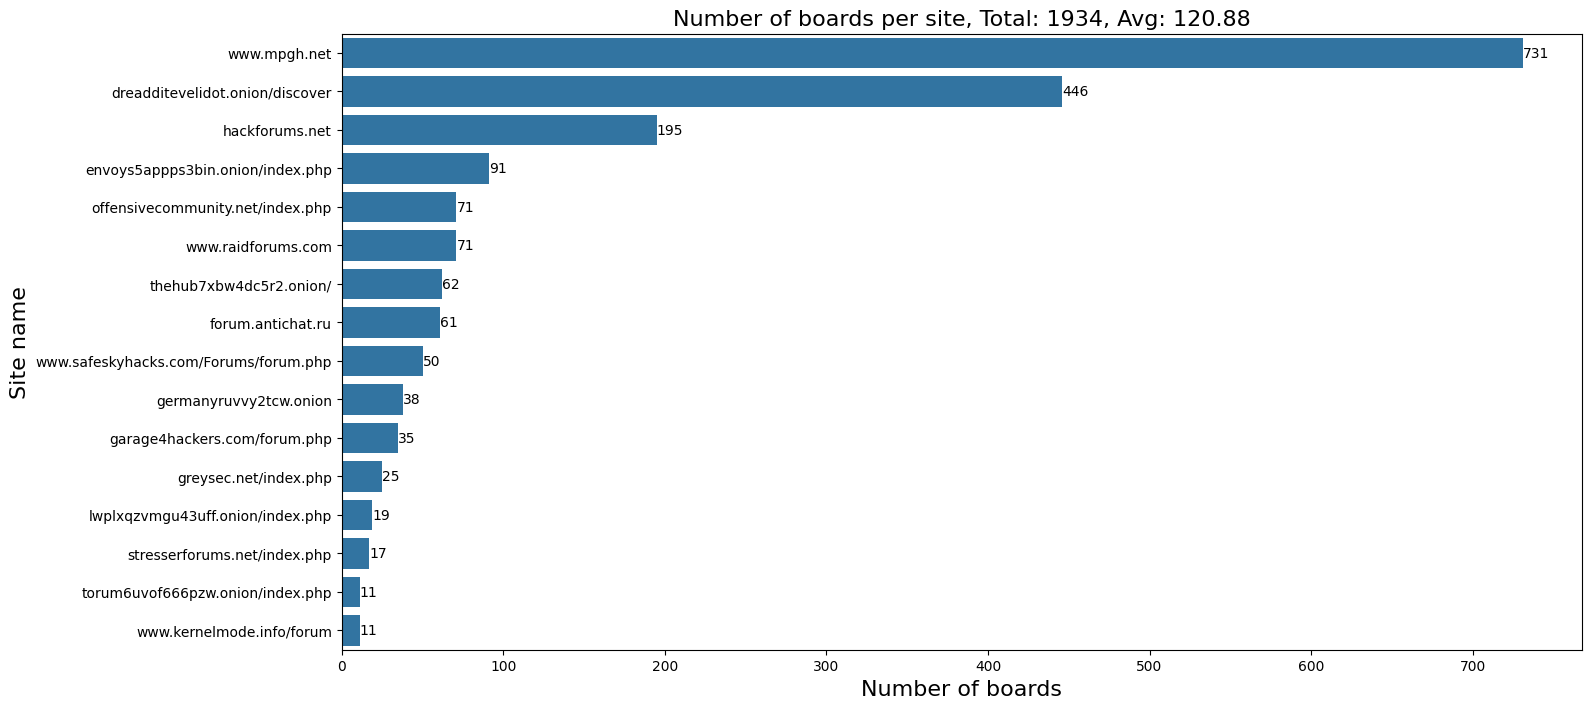

In [32]:
mean_val = round(topics_website_df["num_boards_created"].mean(), 2)
sum_val = round(topics_website_df["num_boards_created"].sum(), 2)

_, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1, sharex=False, sharey=False)

df = topics_website_df.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax
           )

sns_fig.set_title(f"Number of boards per site, Total: {sum_val}, Avg: {mean_val}", fontsize=16)
sns_fig.set_ylabel(f"Site name", fontsize=16)
sns_fig.set_xlabel('Number of boards', fontsize=16)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f')

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

Text(0, 0.5, 'Number of boards')

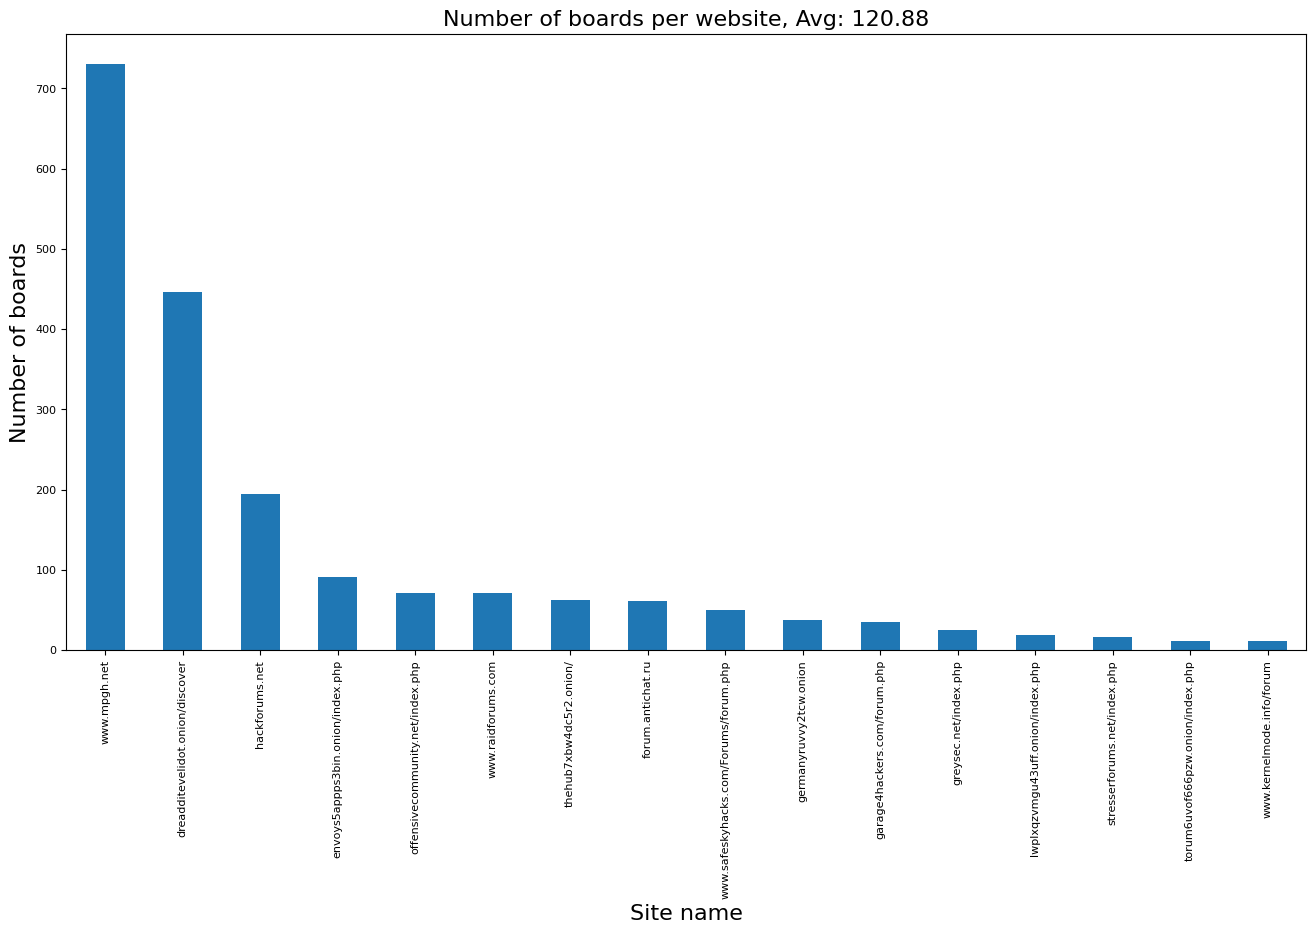

In [33]:
mean_val = round(topics_website_df["num_boards_created"].mean(), 2)

ax = topics_website_df.plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

ax.get_legend().remove()
ax.set_title(f"Number of boards per website, Avg: {mean_val}", fontsize=16)
ax.set_xlabel('Site name', fontsize=16)
ax.set_ylabel(f"Number of boards", fontsize=16)

### Boards x Sites

In [34]:
board_threads_df = pd.merge(threads_df, boards_df[["board_id", "site_id", "site_name", "board_title"]], how="left", on=["site_id", "board_id"])
board_threads_df

,thread_id,site_id,board_id,user_id,username,thread_title,site_name,board_title
0,61028,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban...",offensivecommunity.net/index.php,Announcements
1,60999,3,12,33823,midomark2016,100% social hack successful,offensivecommunity.net/index.php,Announcements
2,60987,3,12,34412,oxlde251,"( Web: http://carder00.com )We Sell CC,CVV,Ban...",offensivecommunity.net/index.php,Announcements
3,13207,3,12,1,Codefire,Advertisement Space,offensivecommunity.net/index.php,Announcements
4,60947,3,12,34455,icceEhackers1234,experience quality hack from icefoghackers wit...,offensivecommunity.net/index.php,Announcements
...,...,...,...,...,...,...,...,...
5258019,5808427,0,219,3683116,L0-kae,I'm looking to buy a custom avatar.,hackforums.net,Graphics Market
5258020,5808056,0,219,1704557,xf0xalz,Curriculum Model,hackforums.net,Graphics Market
5258021,5807686,0,219,3836526,Blake8598,Web Developer/Graphic Designer for hire,hackforums.net,Graphics Market
5258022,5806810,0,219,2737304,Tr0janVirus,Album Cover,hackforums.net,Graphics Market


In [35]:
board_sites_df = pd.pivot_table(board_threads_df[["site_name", "board_id", "username"]].drop_duplicates(),
                                 index=["username", "site_name"],
                                 values=["board_id"],
                                 aggfunc={
                                     "board_id":len
                                 }
                                ).sort_values(by="board_id", ascending=False)#.reset_index(level=0)
board_sites_df.rename(columns={"board_id":"num_boards_interacted"}, inplace=True)
board_sites_df

,,num_boards_interacted
username,site_name,
Effexion,hackforums.net,126
Dave84311,www.mpgh.net,109
Omniscient,hackforums.net,108
'Snorlax,hackforums.net,106
Formula1,hackforums.net,105
...,...,...
SwedishPisces,hackforums.net,1
SwedishTeamKill,hackforums.net,1
SwedishTrades,www.mpgh.net,1


In [36]:
board_sites_ = board_sites_df.pivot_table(columns=['num_boards_interacted'], aggfunc='size')
board_sites_.sort_values(ascending=False, inplace=True)
board_sites_

num_boards_interacted
1      339212
2       93364
3       43149
4       25088
5       16552
        ...  
105         1
106         1
108         1
109         1
126         1
Length: 104, dtype: int64

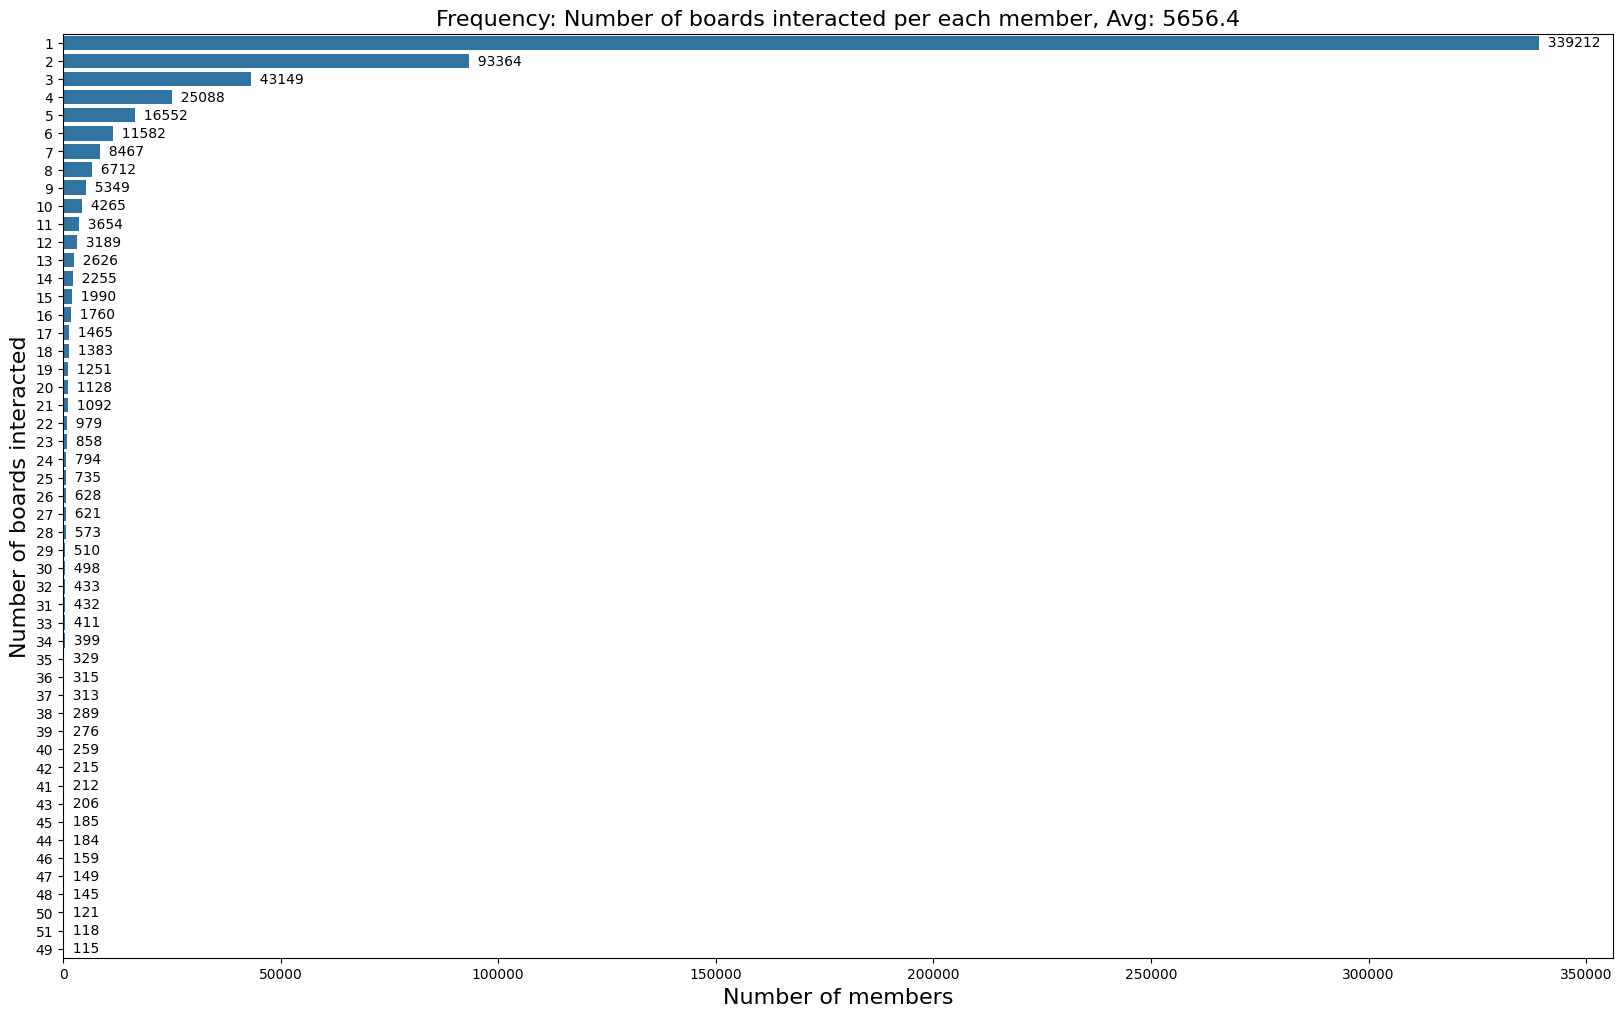

In [37]:
mean_val = round(board_sites_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = board_sites_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of boards interacted per each member, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of members", fontsize=16)
sns_fig.set_ylabel(f"Number of boards interacted", fontsize=16)
sns_fig.set_xticks(range(0,400000,50000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of users')

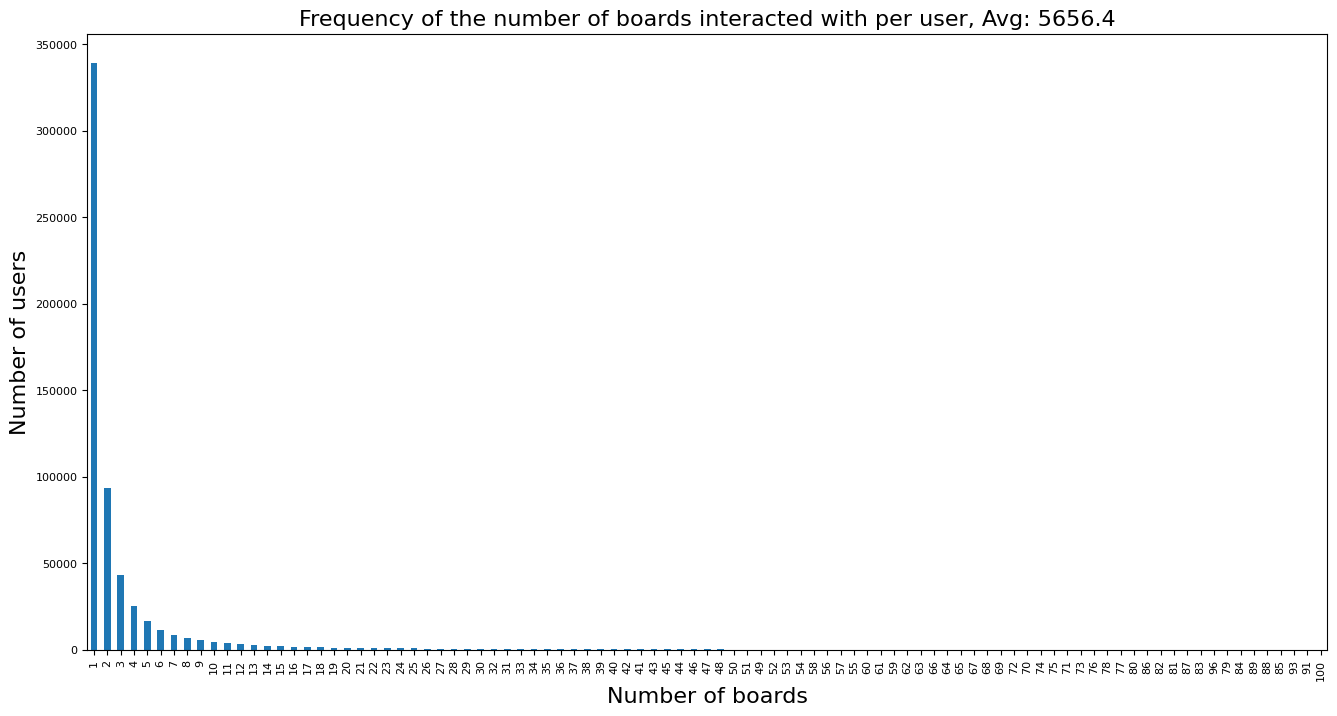

In [38]:
mean_val = round(board_sites_.mean(), 2)

ax = board_sites_.loc[:100].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of boards interacted with per user, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of boards", fontsize=16)
ax.set_ylabel(f"Number of users", fontsize=16)

### Boards x Members

In [39]:
board_member_df = pd.pivot_table(board_threads_df[["board_title", "site_name", "username"]].drop_duplicates(),
                                 index=["board_title", "site_name"],
                                 values=["username"],
                                 aggfunc={
                                     "username":len
                                 }
                                ).sort_values(by="username", ascending=False)#.reset_index(level=0)
board_member_df.rename(columns={"username":"num_members_interacting"}, inplace=True)
board_member_df

,,num_members_interacting
board_title,site_name,
Beginner Hacking,hackforums.net,73329
The Lounge,hackforums.net,66688
Buyers Bay,hackforums.net,48659
Secondary Sellers Market,hackforums.net,34546
Requests for Hacking,hackforums.net,29872
...,...,...
MoneroATMs,dreadditevelidot.onion/discover,1
MyBrute Cheats,www.mpgh.net,1
Antiochus,dreadditevelidot.onion/discover,1


In [40]:
board_member_ = board_member_df.pivot_table(columns=['num_members_interacting'], aggfunc='size')
board_member_.sort_values(ascending=False, inplace=True)
board_member_

num_members_interacting
1      120
2       81
3       68
4       59
5       46
      ... 
427      1
428      1
429      1
430      1
605      1
Length: 675, dtype: int64

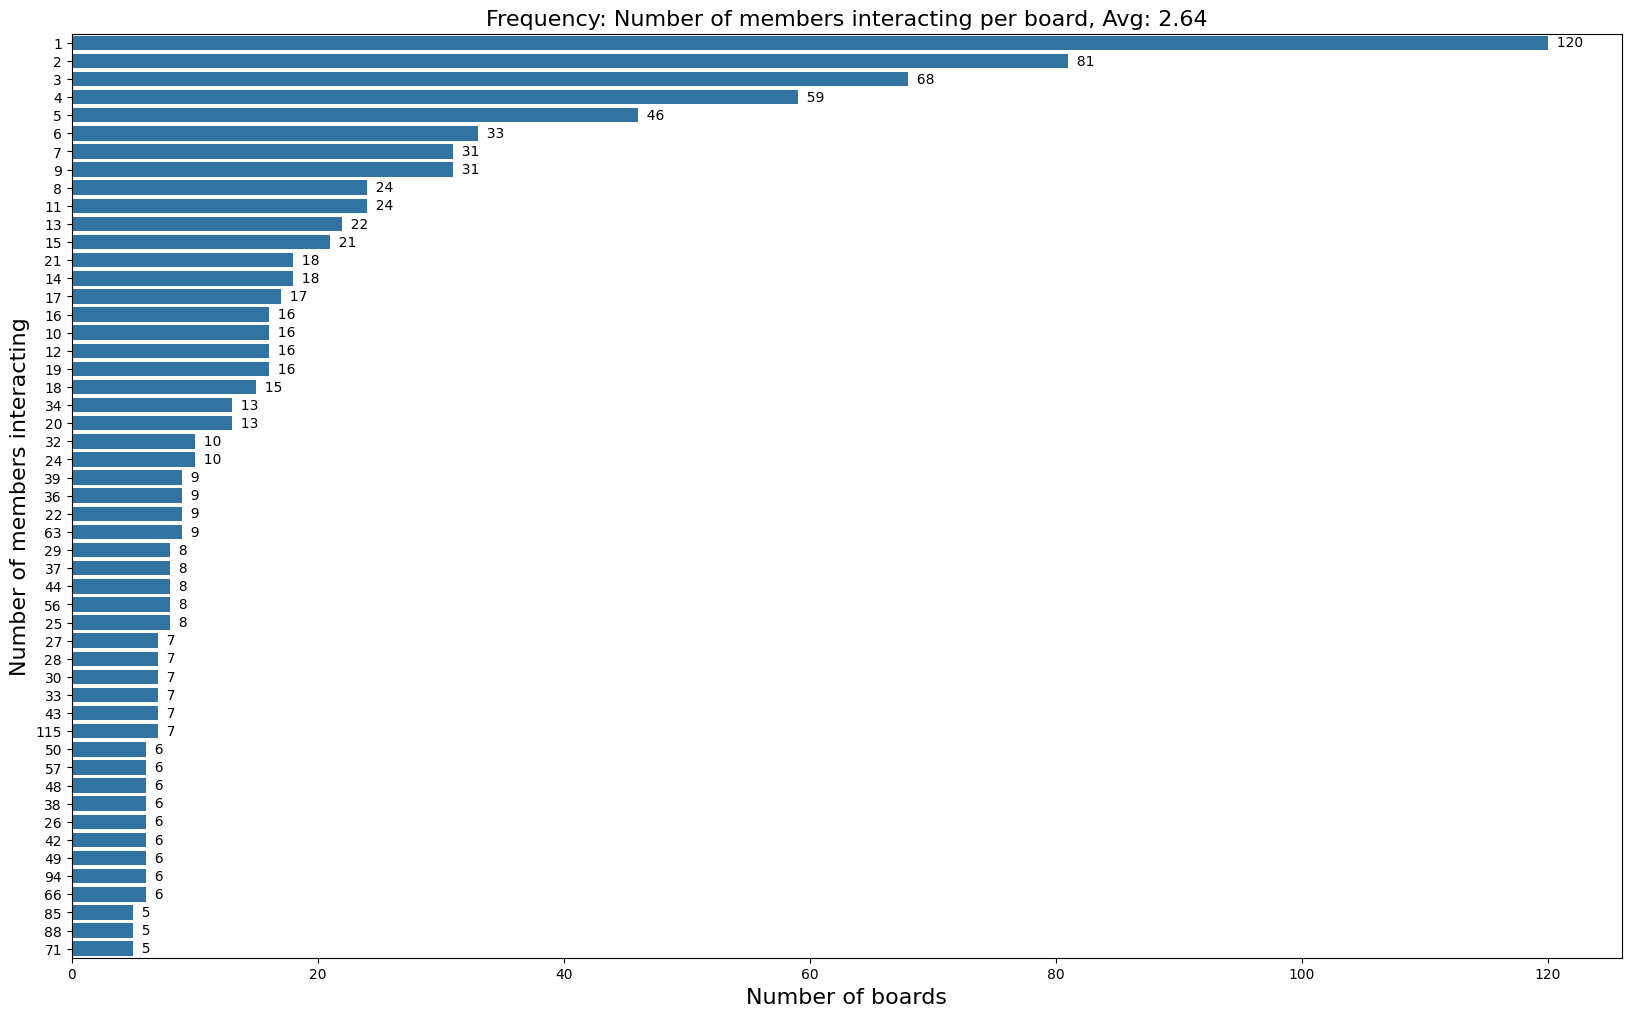

In [41]:
mean_val = round(board_member_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = board_member_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of members interacting per board, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of boards", fontsize=16)
sns_fig.set_ylabel(f"Number of members interacting", fontsize=16)
#sns_fig.set_yticks(range(0,450000,50000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of boards')

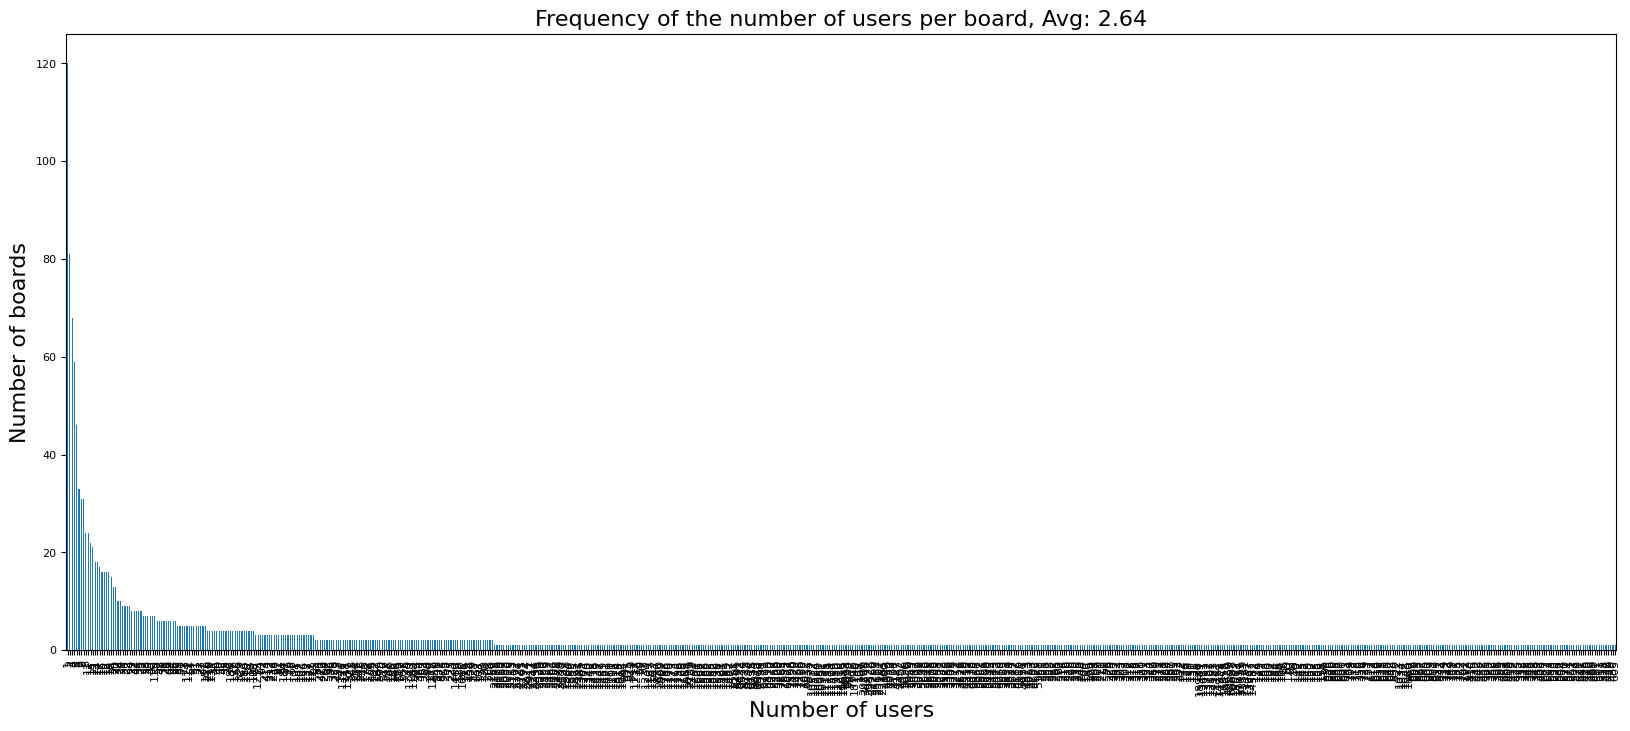

In [42]:
mean_val = round(board_member_.mean(), 2)

ax = board_member_.plot(kind="bar", figsize=(20,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of users per board, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of users", fontsize=16)
ax.set_ylabel("Number of boards", fontsize=16)

### Threads

### Threads x Boards

In [43]:
site_threads_df = pd.pivot_table(board_threads_df,
                 index=["site_name"],
                 values=["thread_id"],
                 aggfunc={
                     "thread_id":len
                 }
                ).sort_values(by="thread_id", ascending=False).reset_index(level=0)
site_threads_df.set_index('site_name', inplace=True)
site_threads_df.rename(columns={"thread_id":"num_threads_created"}, inplace=True)
site_threads_df

,num_threads_created
site_name,
hackforums.net,3978765
www.mpgh.net,767290
forum.antichat.ru,237942
offensivecommunity.net/index.php,119236
dreadditevelidot.onion/discover,65136
www.raidforums.com,34645
lwplxqzvmgu43uff.onion/index.php,16866
www.safeskyhacks.com/Forums/forum.php,12963
thehub7xbw4dc5r2.onion/,11286


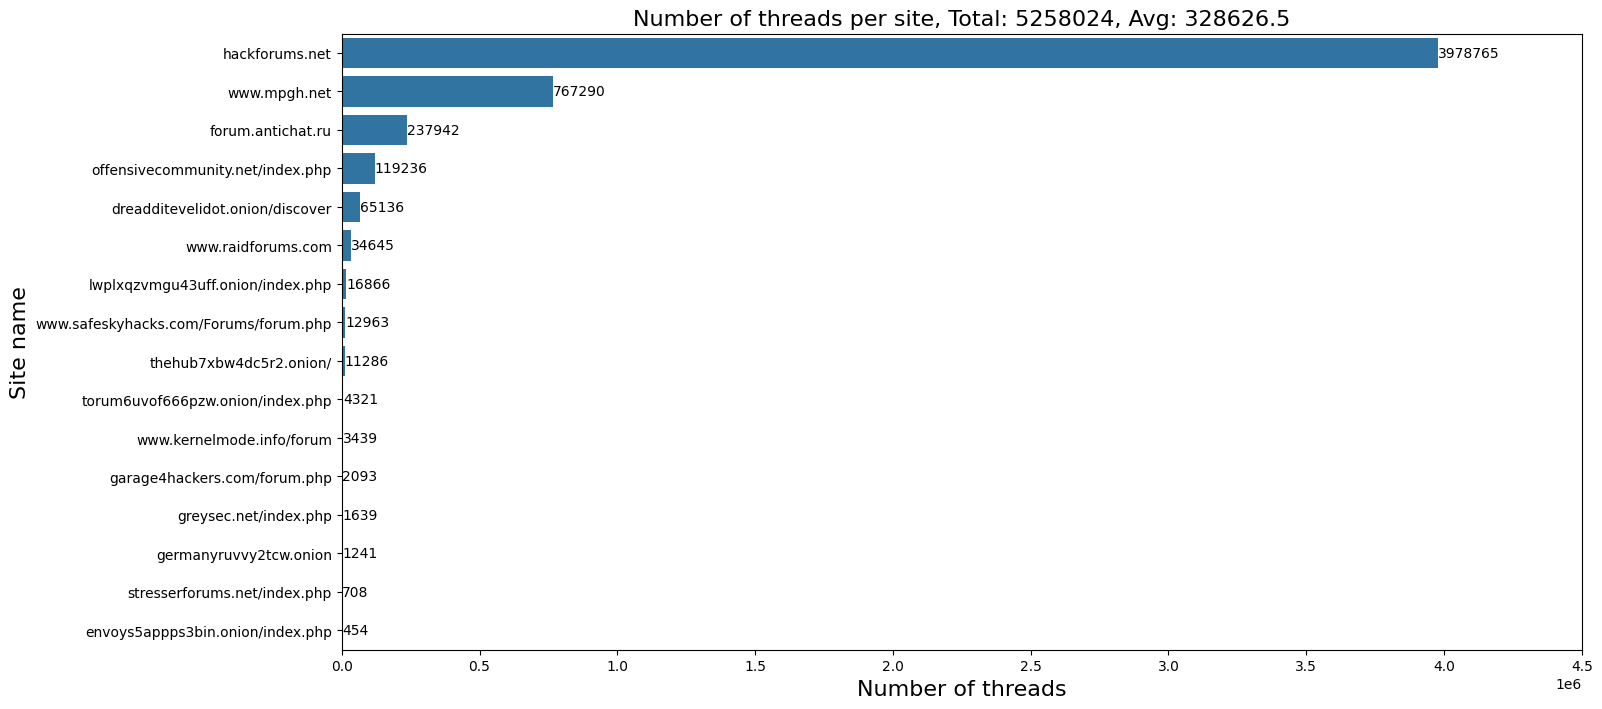

In [44]:
mean_val = round(site_threads_df["num_threads_created"].mean(), 2)
sum_val = round(site_threads_df["num_threads_created"].sum(), 2)

_, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1, sharex=False, sharey=False)

df = site_threads_df.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax
           )

sns_fig.set_title(f"Number of threads per site, Total: {sum_val}, Avg: {mean_val}", fontsize=16)
sns_fig.set_ylabel(f"Site name", fontsize=16)
sns_fig.set_xlabel('Number of threads', fontsize=16)
sns_fig.set_xticks(range(0,5000000,500000))

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f')

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

Text(0, 0.5, 'Number of threads')

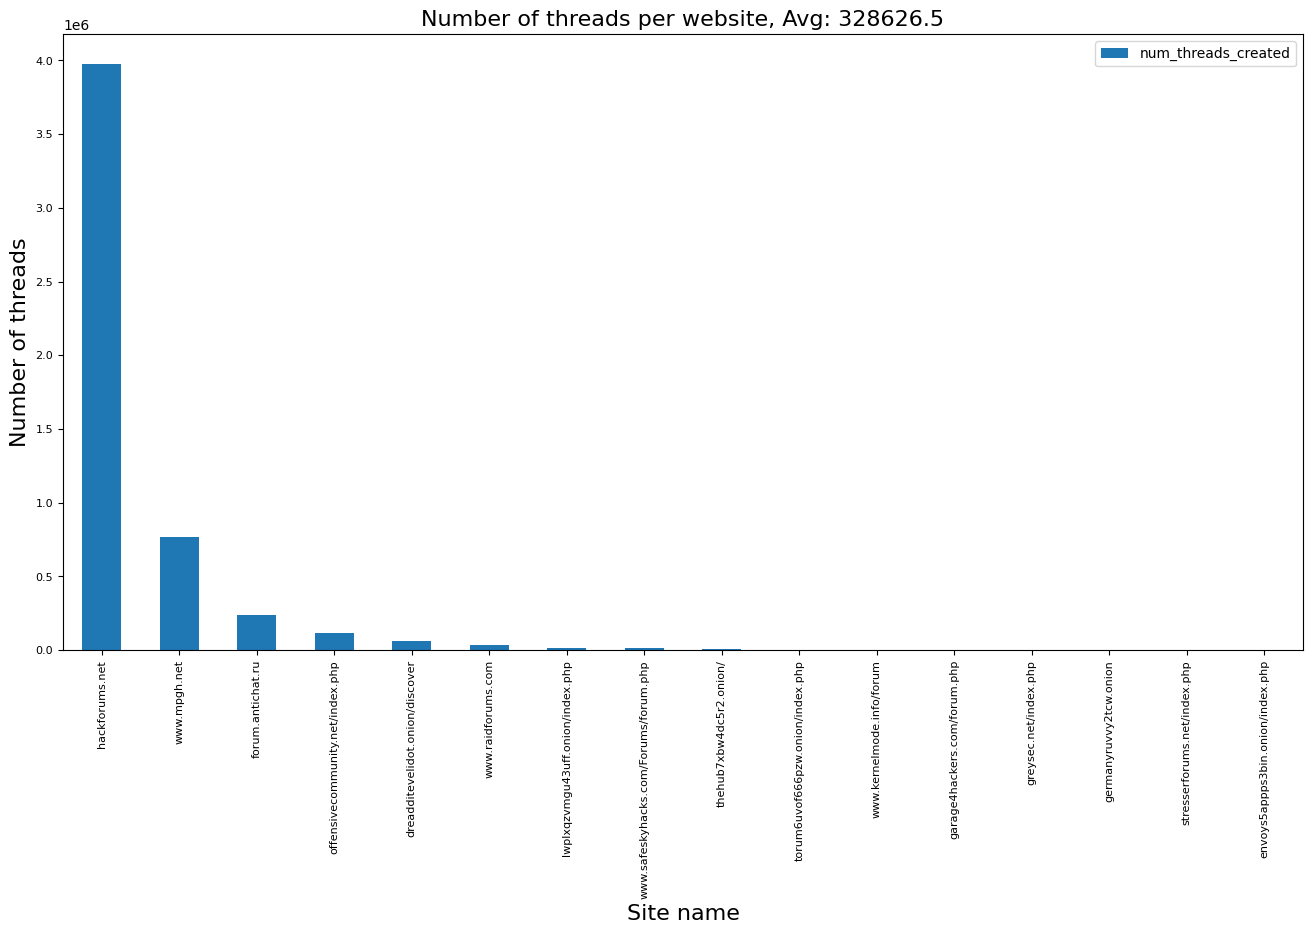

In [45]:
mean_val = round(site_threads_df["num_threads_created"].mean(), 2)

ax = site_threads_df.plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Number of threads per website, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Site name", fontsize=16)
ax.set_ylabel("Number of threads", fontsize=16)

### Threads x Sites

In [46]:
thread_sites_df = pd.pivot_table(board_threads_df[["site_name", "thread_id", "username"]].drop_duplicates(),
                                 index=["username", "site_name"],
                                 values=["thread_id"],
                                 aggfunc={
                                     "thread_id":len
                                 }
                                ).sort_values(by="thread_id", ascending=False)#.reset_index(level=0)
thread_sites_df.rename(columns={"thread_id":"num_threads_interacted"}, inplace=True)
thread_sites_df

,,num_threads_interacted
username,site_name,
alremmohc,offensivecommunity.net/index.php,31680
onbassoh,offensivecommunity.net/index.php,31662
ArdisCu,offensivecommunity.net/index.php,8283
LynettaCo,offensivecommunity.net/index.php,7066
Omniscient,hackforums.net,4106
...,...,...
akmorron,hackforums.net,1
akmal8,hackforums.net,1
akmafia001,hackforums.net,1


In [47]:
thread_sites_ = thread_sites_df.pivot_table(columns=['num_threads_interacted'], aggfunc='size')
thread_sites_.sort_values(ascending=False, inplace=True)
thread_sites_

num_threads_interacted
1      284795
2       88115
3       45070
4       27770
5       19161
        ...  
687         1
689         1
692         1
694         1
658         1
Length: 839, dtype: int64

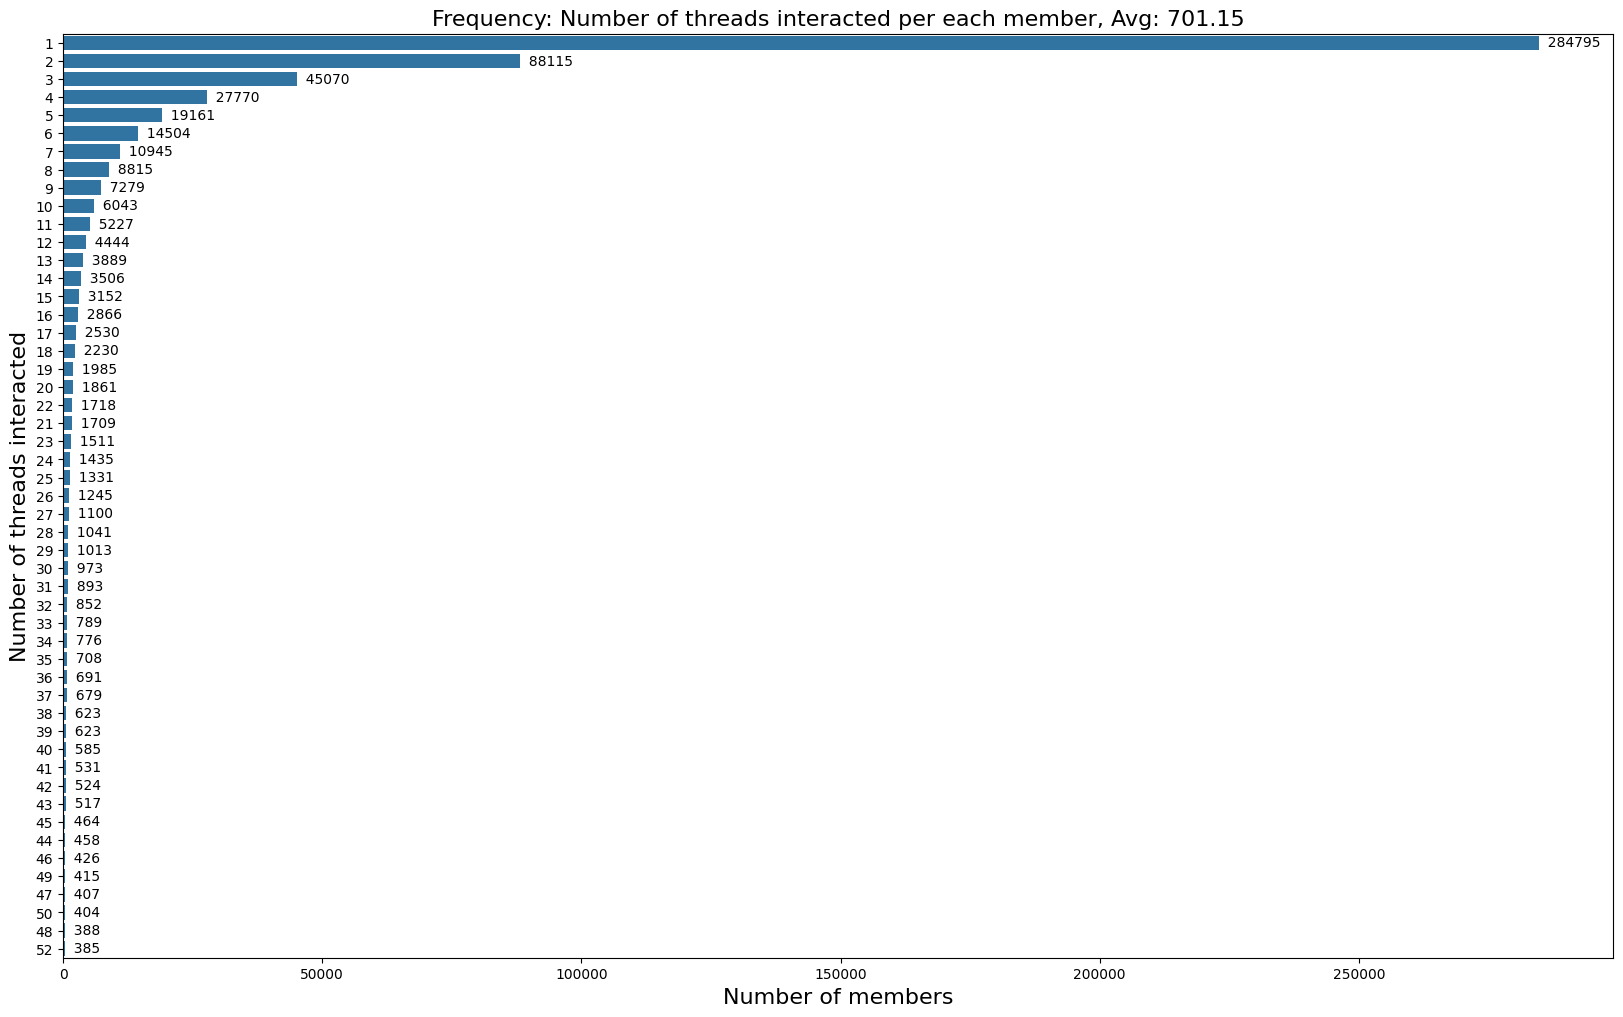

In [48]:
mean_val = round(thread_sites_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = thread_sites_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of threads interacted per each member, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of members", fontsize=16)
sns_fig.set_ylabel(f"Number of threads interacted", fontsize=16)
# sns_fig.set_yticks(range(0,400000,50000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of users')

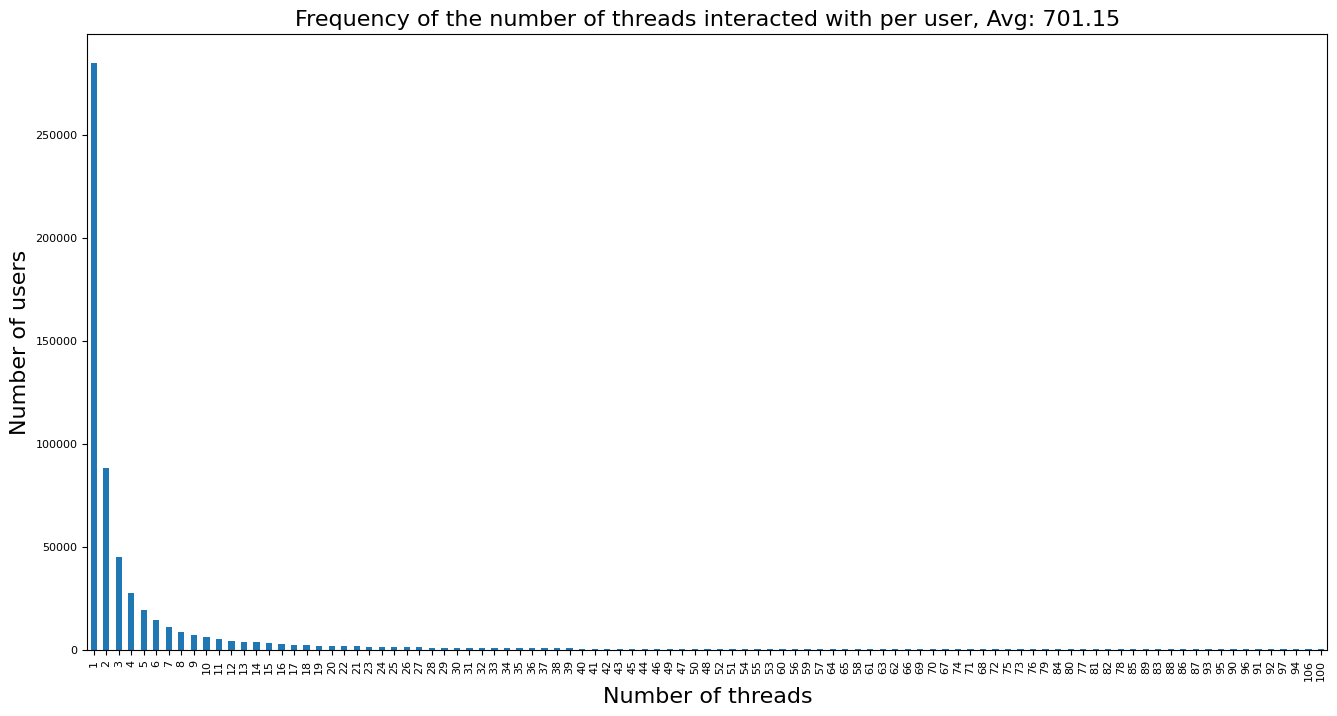

In [49]:
mean_val = round(thread_sites_.mean(), 2)

ax = thread_sites_.loc[:100].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of threads interacted with per user, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of threads", fontsize=16)
ax.set_ylabel("Number of users", fontsize=16)

### Threads x Members

In [50]:
thread_members_df = pd.pivot_table(board_threads_df[["thread_title", "site_name", "username"]].drop_duplicates(),
                                 index=["thread_title", "site_name"],
                                 values=["username"],
                                 aggfunc={
                                     "username":len
                                 }
                                ).sort_values(by="username", ascending=False)#.reset_index(level=0)
thread_members_df.rename(columns={"username":"num_members_interacting"}, inplace=True)
thread_members_df

,,num_members_interacting
thread_title,site_name,
Closed,hackforums.net,2438
Help,hackforums.net,1669
Question,hackforums.net,1522
closed,hackforums.net,1326
Hello,hackforums.net,1285
...,...,...
Imminent Monitor 3 FUD Crypt!,hackforums.net,1
"Imminent Monitor 3 Error (Oops, something went wrong)",hackforums.net,1
Imminent Monitor 3 Download ?,hackforums.net,1


In [51]:
thread_members_ = thread_members_df.pivot_table(columns=['num_members_interacting'], aggfunc='size')
thread_members_.sort_values(ascending=False, inplace=True)
thread_members_

num_members_interacting
1       4469110
2         83504
3         23059
4         10709
5          5988
         ...   
449           1
455           1
1522          1
1669          1
2438          1
Length: 259, dtype: int64

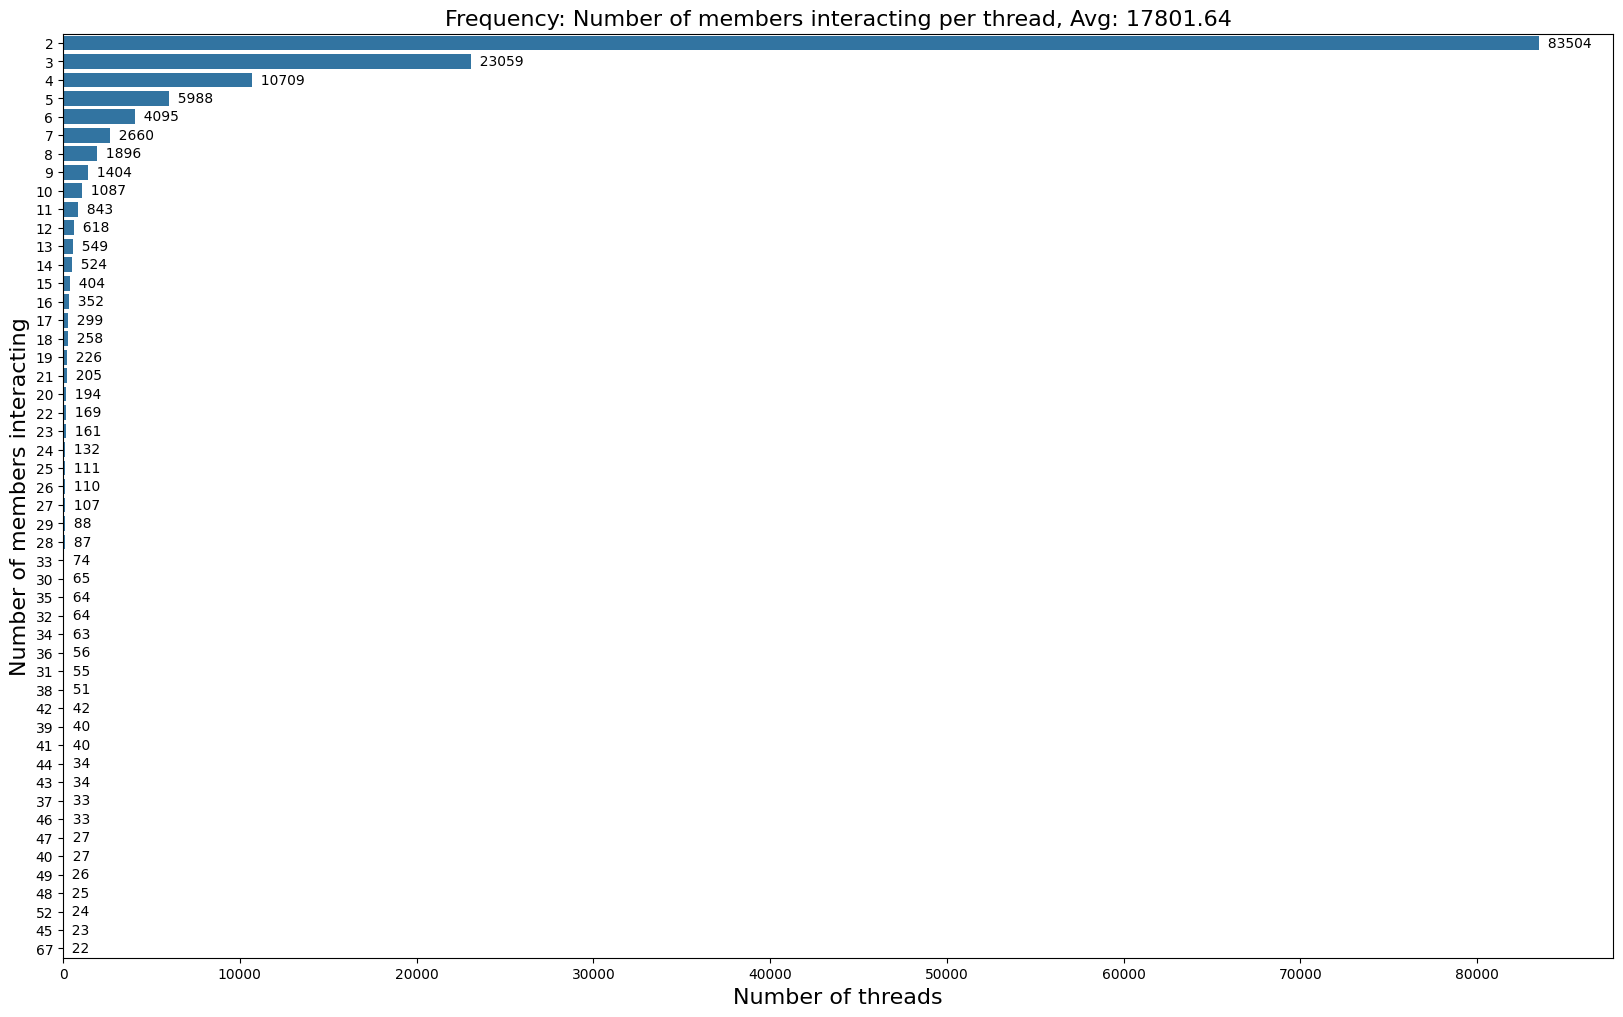

In [52]:
mean_val = round(thread_members_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = thread_members_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[1:50]
          )

sns_fig.set_title(f"Frequency: Number of members interacting per thread, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of threads", fontsize=16)
sns_fig.set_ylabel(f"Number of members interacting", fontsize=16)
# sns_fig.set_yticks(range(0,95000,5000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of threads')

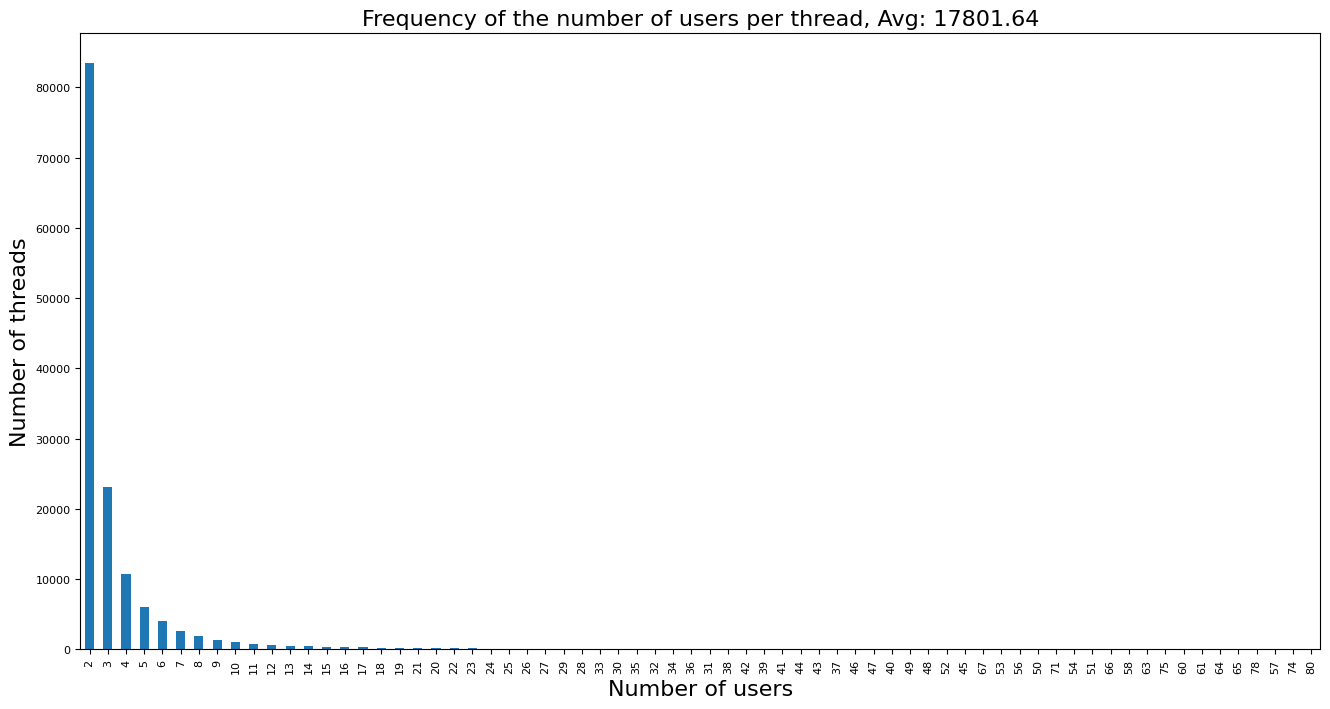

In [53]:
mean_val = round(thread_members_.mean(), 2)

ax = thread_members_.loc[2:80].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of users per thread, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of users", fontsize=16)
ax.set_ylabel("Number of threads", fontsize=16)

### Threads x Boards

In [54]:
thread_board_df = pd.pivot_table(board_threads_df[["site_name", "thread_id", "board_title", "board_id"]].drop_duplicates(),
                              index=["board_title", "site_name", "board_id"],
                              values=["thread_id"],
                              aggfunc={
                                 "thread_id":len
                              }).sort_values(by="thread_id", ascending=False)
thread_board_df.rename(columns={"thread_id":"num_threads_created"}, inplace=True)
thread_board_df.reset_index(inplace=True)
thread_board_df.set_index(["board_title", "site_name"], inplace=True)
thread_board_df.drop(columns=['board_id'], inplace=True)
thread_board_df

,,num_threads_created
board_title,site_name,
The Lounge,hackforums.net,548127
Buyers Bay,hackforums.net,255486
Beginner Hacking,hackforums.net,189198
Secondary Sellers Market,hackforums.net,136687
Currency Exchange,hackforums.net,97914
...,...,...
Arcade Games,www.mpgh.net,1
Stoners Only,envoys5appps3bin.onion/index.php,1
AnnieAdderall,dreadditevelidot.onion/discover,1


In [55]:
thread_board_df_ = thread_board_df.pivot_table(columns=['num_threads_created'], aggfunc='size')
thread_board_df_.sort_values(ascending=False, inplace=True)
thread_board_df_

num_threads_created
1      70
2      64
3      63
4      49
8      34
       ..
810     1
817     1
818     1
819     1
778     1
Length: 779, dtype: int64

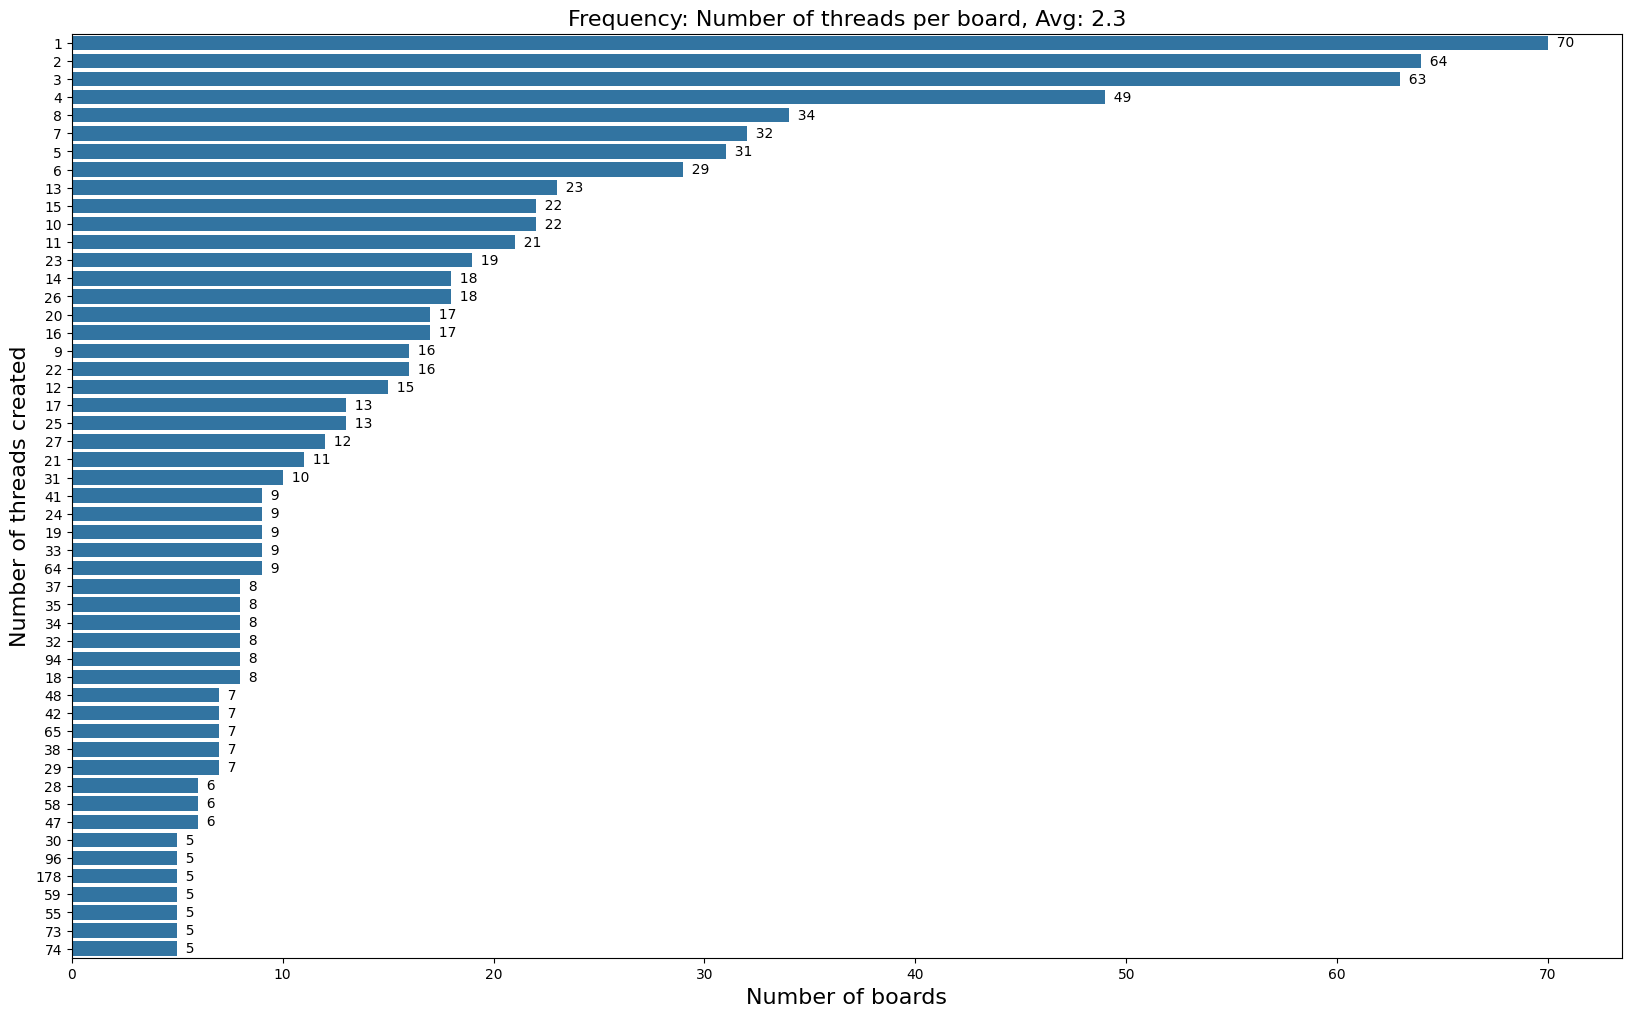

In [56]:
mean_val = round(thread_board_df_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = thread_board_df_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of threads per board, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of boards", fontsize=16)
sns_fig.set_ylabel(f"Number of threads created", fontsize=16)
# sns_fig.set_yticks(range(0,95000,5000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of boards')

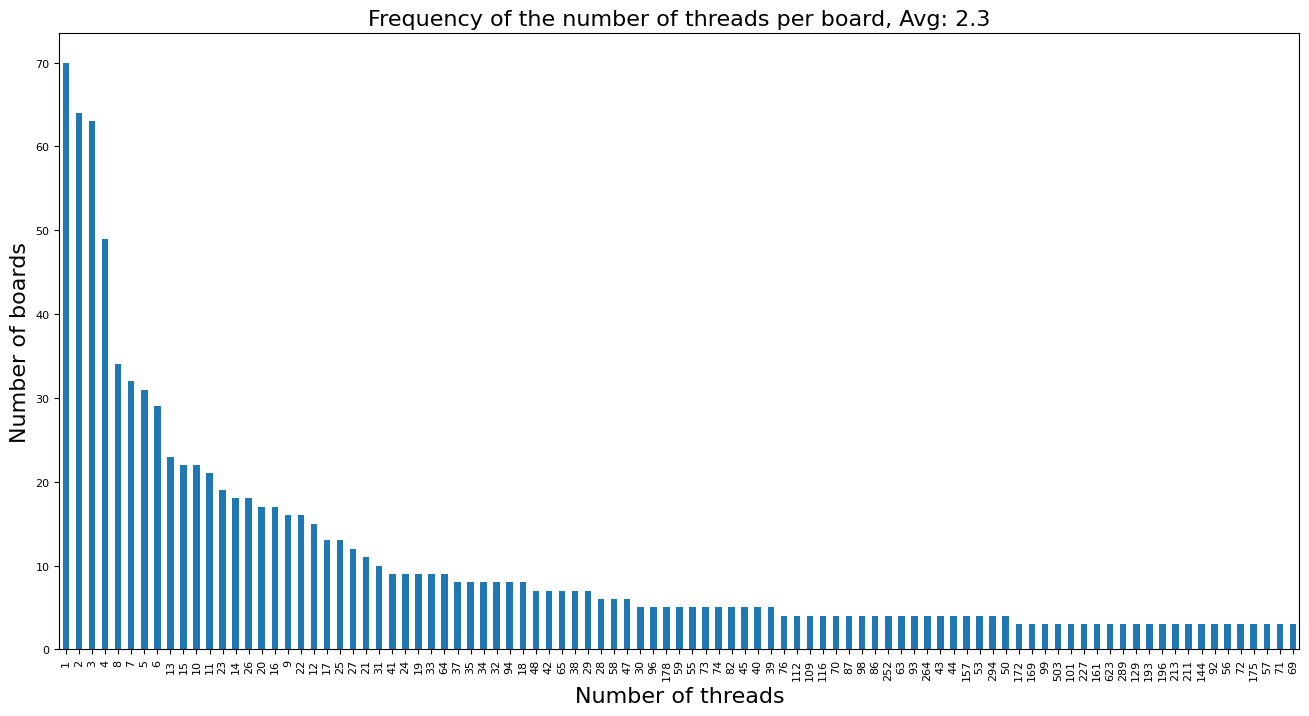

In [57]:
mean_val = round(thread_board_df_.mean(), 2)

ax = thread_board_df_.loc[:69].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of threads per board, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of threads", fontsize=16)
ax.set_ylabel("Number of boards", fontsize=16)

### Posts

#### Posts x Website

In [58]:
posts_website_df = pd.merge(posts_df, website_df, how="left", on="site_id")
posts_website_df

,post_id,site_id,board_id,thread_id,user_id,username,user_reputation,content,post_data_creation,site_name
0,24355,3,19,5,22290,NaN,0,"thanks, for this great tutorial!",2015-12-25 09:56:00-02,offensivecommunity.net/index.php
1,23917,3,19,5,22115,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-12-13 08:14:00-02,offensivecommunity.net/index.php
2,12023,3,19,5,19519,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-07-23 23:18:00-03,offensivecommunity.net/index.php
3,2,3,19,5,27,NaN,0,It's good to see such a valuable information o...,2012-06-30 08:49:00-03,offensivecommunity.net/index.php
4,8,3,19,5,26,NaN,0,Perfect one!!!\neasy to learn with such kind o...,2012-06-30 07:48:00-03,offensivecommunity.net/index.php
...,...,...,...,...,...,...,...,...,...,...
54443382,59064545,0,32,6017249,2663062,Donald Trump Jr.,80,Get NordVpn or ProtonVpn Protonvpn definitely ...,2019-10-18 02:02:00-03,hackforums.net
54443383,59064520,0,32,6017249,1201566,Natas,1042,Nord is a good vpn u will be ight,2019-10-18 01:48:00-03,hackforums.net
54443384,59064512,0,32,6017249,4388154,Hoopinkid,8,I got a isp warning recently using popcorn tim...,2019-10-18 01:43:00-03,hackforums.net
54443385,59065236,0,32,6017325,4395338,Nsane Warez,0,anyone need a invite to the scene holla!!,2019-10-18 09:26:00-03,hackforums.net


In [59]:
post_x_website = pd.pivot_table(posts_website_df[["site_name", "post_id"]].drop_duplicates(),
                              index=["site_name"],
                              values=["post_id"],
                              aggfunc={
                                 "post_id":len
                              }).sort_values(by="post_id", ascending=False)
post_x_website.rename(columns={"post_id":"num_posts_created"}, inplace=True)
post_x_website.reset_index(inplace=True)
post_x_website.set_index(["site_name"], inplace=True)
post_x_website

,num_posts_created
site_name,
hackforums.net,41571269
www.mpgh.net,9363422
forum.antichat.ru,2449396
lwplxqzvmgu43uff.onion/index.php,240628
dreadditevelidot.onion/discover,236103
www.raidforums.com,214856
offensivecommunity.net/index.php,161492
thehub7xbw4dc5r2.onion/,88753
torum6uvof666pzw.onion/index.php,28485


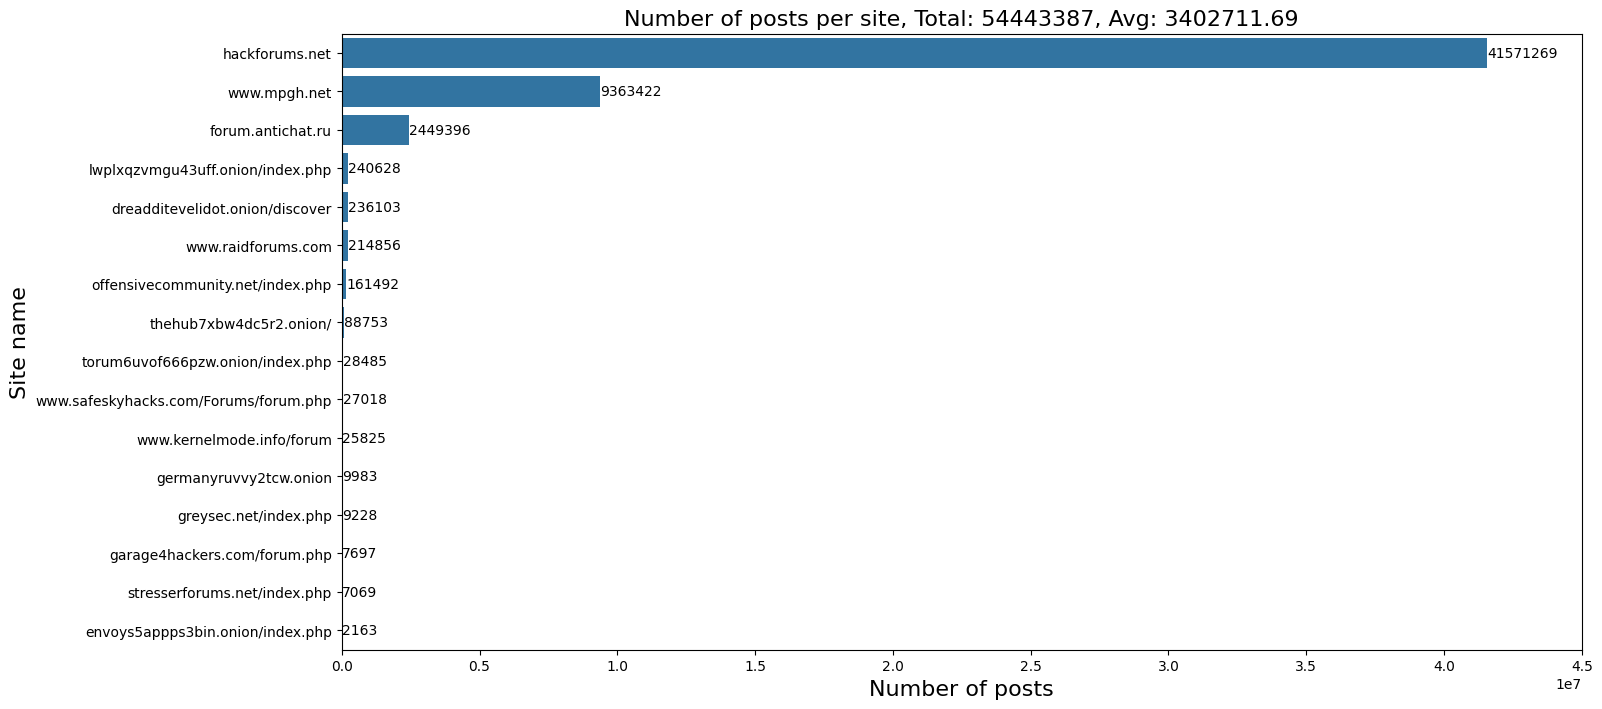

In [60]:
mean_val = round(post_x_website["num_posts_created"].mean(), 2)
sum_val = round(post_x_website["num_posts_created"].sum(), 2)

_, ax = plt.subplots(figsize=(16,8), nrows=1, ncols=1, sharex=False, sharey=False)

df = post_x_website.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax
           )

sns_fig.set_title(f"Number of posts per site, Total: {sum_val}, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel(f"Number of posts", fontsize=16)
sns_fig.set_ylabel('Site name', fontsize=16)
sns_fig.set_xticks(range(0,50000000,5000000))

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f')

# add a space on y for the annotations
#sns_fig.margins(x=0.1)

Text(0, 0.5, 'Number of posts')

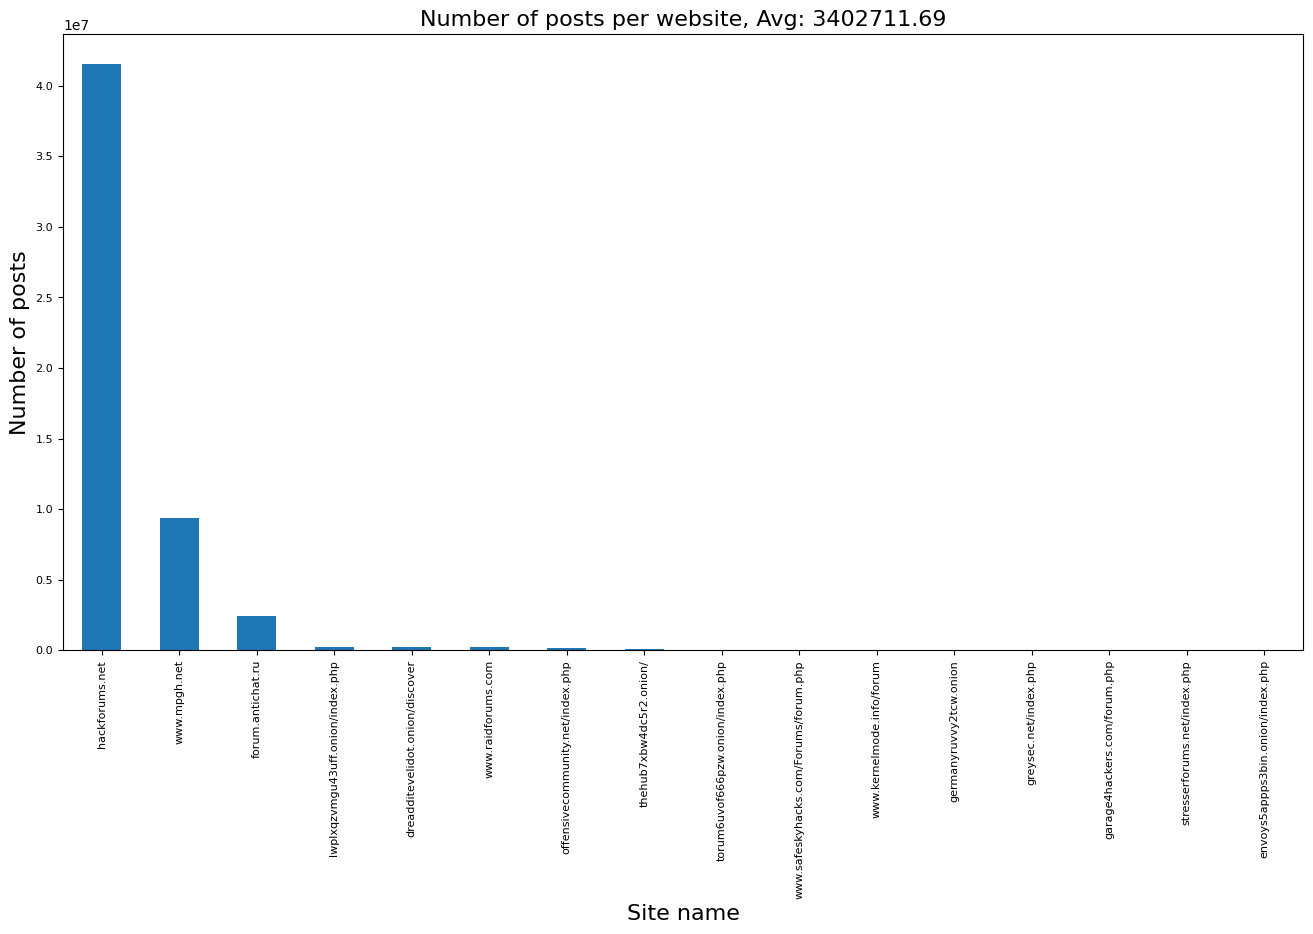

In [61]:
mean_val = round(post_x_website["num_posts_created"].mean(), 2)

ax = post_x_website.plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

ax.get_legend().remove()
ax.set_title(f"Number of posts per website, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Site name", fontsize=16)
ax.set_ylabel("Number of posts", fontsize=16)

#### Posts x sites

In [62]:
post_sites_df = pd.pivot_table(posts_website_df[["site_name", "post_id", "username"]].drop_duplicates(),
                                 index=["username", "site_name"],
                                 values=["post_id"],
                                 aggfunc={
                                     "post_id":len
                                 }
                                ).sort_values(by="post_id", ascending=False)#.reset_index(level=0)
post_sites_df.rename(columns={"post_id":"num_posts_created"}, inplace=True)
post_sites_df

,,num_posts_created
username,site_name,
Vitani's Mate.,hackforums.net,79833
Omniscient,hackforums.net,44436
Grin,hackforums.net,43589
Mr. Robot,hackforums.net,34315
Aurа,hackforums.net,34079
...,...,...
horsehead17,hackforums.net,1
horseboy97,www.mpgh.net,1
horsethief,www.mpgh.net,1


In [63]:
post_sites_ = post_sites_df.pivot_table(columns=['num_posts_created'], aggfunc='size')
post_sites_.sort_values(ascending=False, inplace=True)
post_sites_

num_posts_created
1        452613
2        173433
3         99170
4         67339
5         51092
          ...  
29786         1
29940         1
18026         1
18109         1
18231         1
Length: 4767, dtype: int64

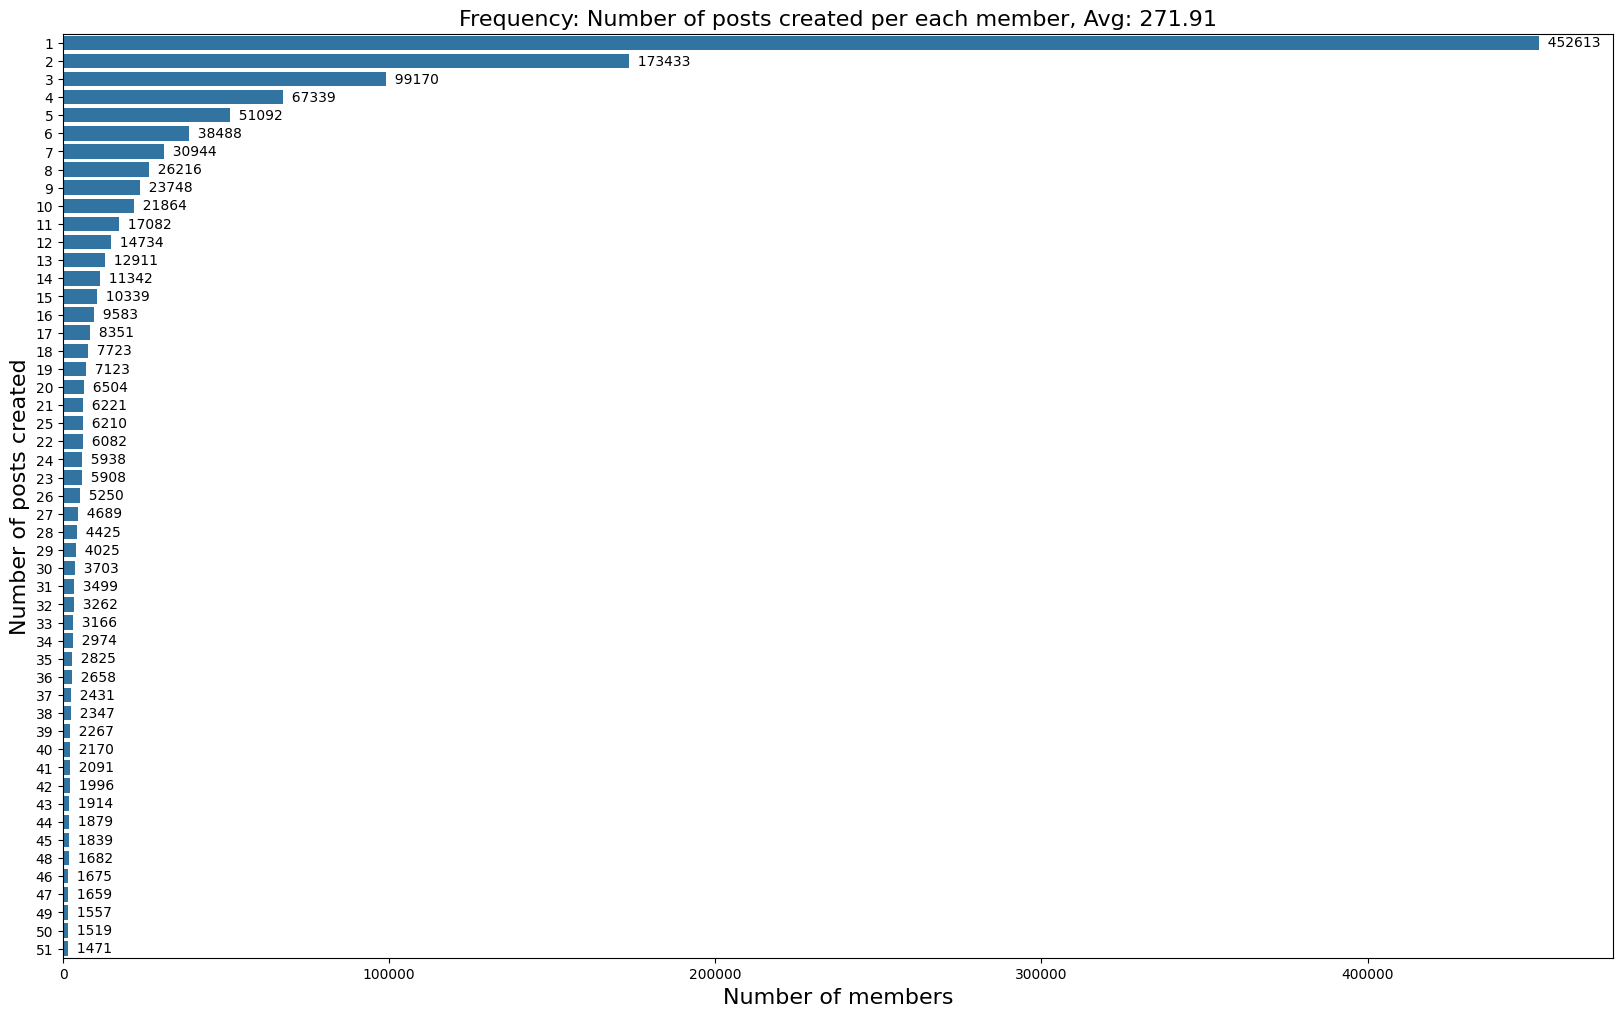

In [64]:
mean_val = round(post_sites_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = post_sites_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of posts created per each member, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of members", fontsize=16)
sns_fig.set_ylabel(f"Number of posts created", fontsize=16)
# sns_fig.set_yticks(range(0,400000,50000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of users')

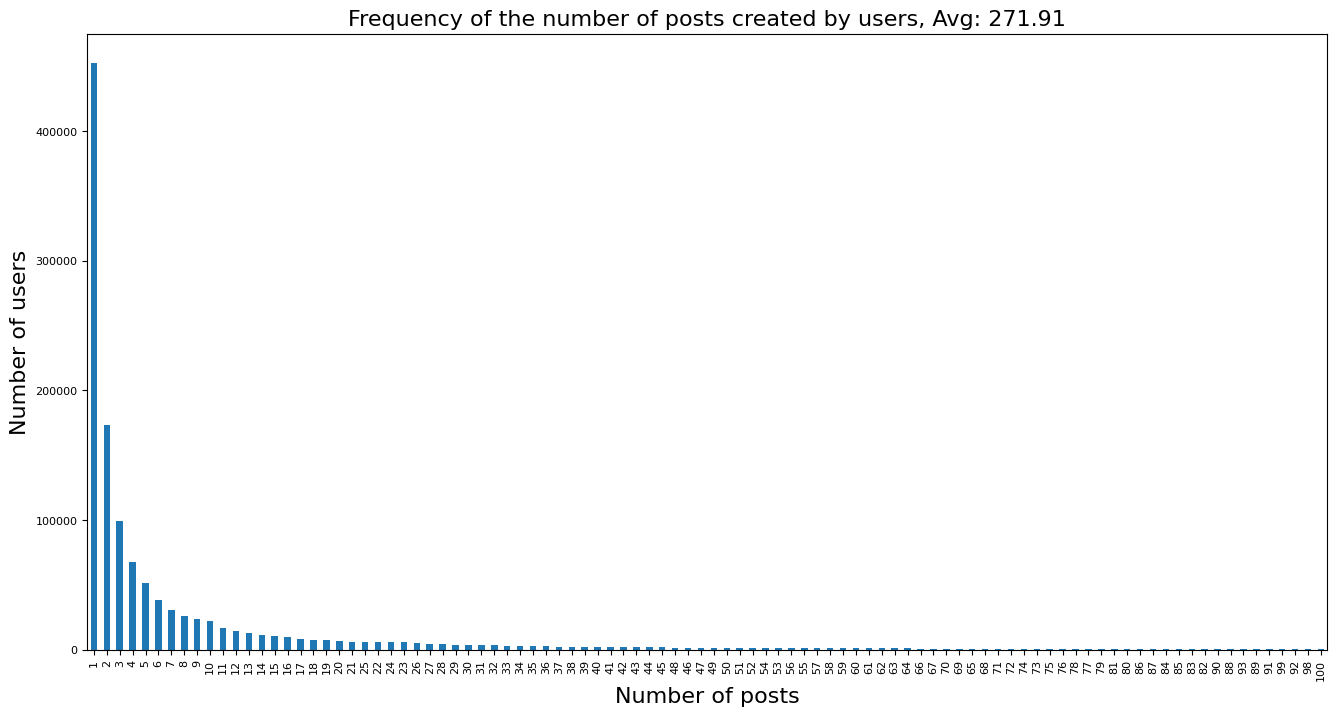

In [65]:
mean_val = round(post_sites_.mean(), 2)

ax = post_sites_.loc[:100].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of posts created by users, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of posts", fontsize=16)
ax.set_ylabel("Number of users", fontsize=16)

#### Posts x members

In [66]:
# post_member_df = pd.pivot_table(posts_website_df[["site_name", "post_id", "username"]].drop_duplicates(),
#                                  index=["username", "site_name"],
#                                  values=["post_id"],
#                                  aggfunc={
#                                      "post_id":len
#                                  }
#                                 ).sort_values(by="post_id", ascending=False)#.reset_index(level=0)
# post_member_df.rename(columns={"post_id":"num_posts_created"}, inplace=True)
# post_member_df

In [67]:
# post_members_ = post_member_df.pivot_table(columns=['num_posts_created'], aggfunc='size')
# post_members_.sort_values(ascending=False, inplace=True)
# post_members_

In [68]:
# mean_val = round(post_sites_.mean(), 2)

# ax = post_members_.loc[:100].plot(kind="bar", figsize=(16,8), title=f"Frequencia dos numeros de posts criados por usuario/website, Avg: {mean_val}", xlabel="Número de posts criados", ylabel="Frequencia de posts", rot=90)
# # ax.legend(list(temp_df["site_name"]))
# #ax.get_legend().remove()

#### Posts x Boards

In [69]:
posts_boards_df = pd.merge(posts_website_df, boards_df[["site_id", "board_id", "board_title"]].drop_duplicates(), on=["site_id", "board_id"], how="left")
posts_boards_df

,post_id,site_id,board_id,thread_id,user_id,username,user_reputation,content,post_data_creation,site_name,board_title
0,24355,3,19,5,22290,NaN,0,"thanks, for this great tutorial!",2015-12-25 09:56:00-02,offensivecommunity.net/index.php,Advanced Hacking Tutorials
1,23917,3,19,5,22115,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-12-13 08:14:00-02,offensivecommunity.net/index.php,Advanced Hacking Tutorials
2,12023,3,19,5,19519,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-07-23 23:18:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials
3,2,3,19,5,27,NaN,0,It's good to see such a valuable information o...,2012-06-30 08:49:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials
4,8,3,19,5,26,NaN,0,Perfect one!!!\neasy to learn with such kind o...,2012-06-30 07:48:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials
...,...,...,...,...,...,...,...,...,...,...,...
54443382,59064545,0,32,6017249,2663062,Donald Trump Jr.,80,Get NordVpn or ProtonVpn Protonvpn definitely ...,2019-10-18 02:02:00-03,hackforums.net,"Movies, TV, and Videos"
54443383,59064520,0,32,6017249,1201566,Natas,1042,Nord is a good vpn u will be ight,2019-10-18 01:48:00-03,hackforums.net,"Movies, TV, and Videos"
54443384,59064512,0,32,6017249,4388154,Hoopinkid,8,I got a isp warning recently using popcorn tim...,2019-10-18 01:43:00-03,hackforums.net,"Movies, TV, and Videos"
54443385,59065236,0,32,6017325,4395338,Nsane Warez,0,anyone need a invite to the scene holla!!,2019-10-18 09:26:00-03,hackforums.net,"Movies, TV, and Videos"


In [70]:
post_board_df = pd.pivot_table(posts_boards_df[["site_name", "board_title", "board_id", "post_id"]].drop_duplicates(),
                                 index=["board_title", "site_name", "board_id"],
                                 values=["post_id"],
                                 aggfunc={
                                     "post_id":len
                                 }
                                ).sort_values(by="post_id", ascending=False)#.reset_index(level=0)
post_board_df.rename(columns={"post_id":"num_posts_created"}, inplace=True)
post_board_df.reset_index(inplace=True)
post_board_df.set_index(["board_title", "site_name"], inplace=True)
post_board_df.drop(columns=['board_id'], inplace=True)
post_board_df

,,num_posts_created
board_title,site_name,
The Lounge,hackforums.net,8342914
Premium Sellers Section,hackforums.net,1551368
Free Services and Giveaways,hackforums.net,1361720
Beginner Hacking,hackforums.net,1241260
Buyers Bay,hackforums.net,1093884
...,...,...
News and Media Reports,envoys5appps3bin.onion/index.php,1
Halbmensch,dreadditevelidot.onion/discover,1
MarketsUruguay,dreadditevelidot.onion/discover,1


In [71]:
post_board_df_ = post_board_df.pivot_table(columns=['num_posts_created'], aggfunc='size')
post_board_df_.sort_values(ascending=False, inplace=True)
post_board_df_

num_posts_created
1       30
2       26
3       24
4       21
6       21
        ..
1653     1
1664     1
1679     1
1685     1
1542     1
Length: 1132, dtype: int64

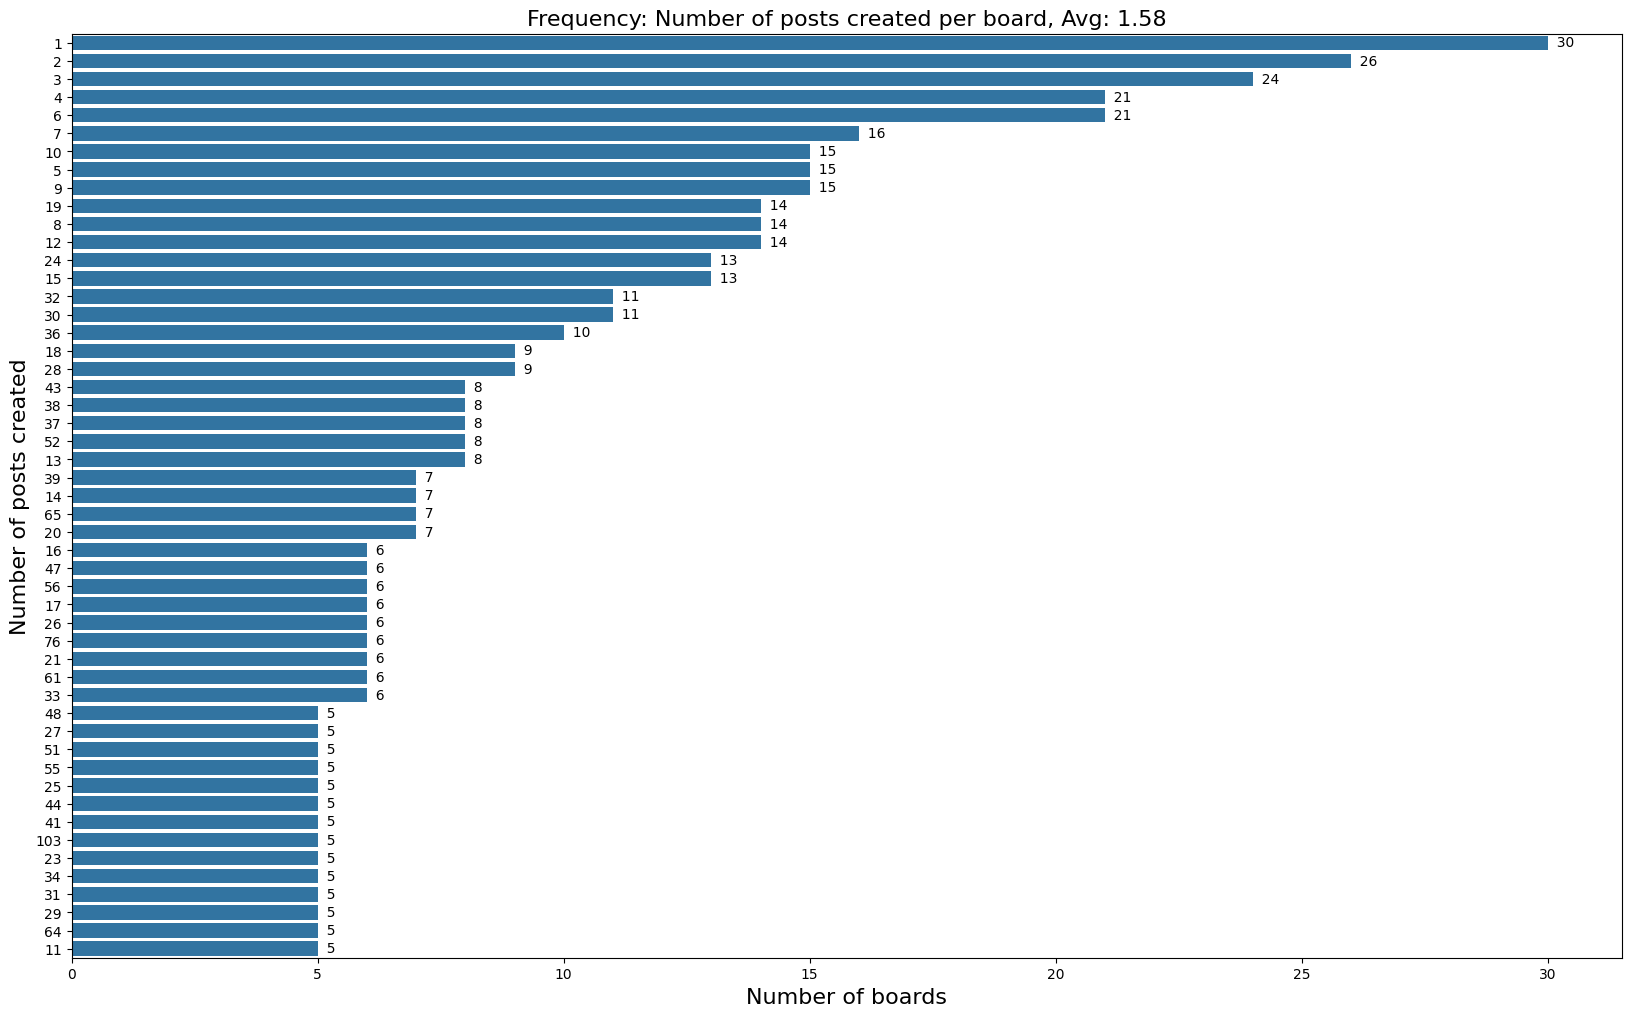

In [72]:
mean_val = round(post_board_df_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = post_board_df_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of posts created per board, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of boards", fontsize=16)
sns_fig.set_ylabel(f"Number of posts created", fontsize=16)
# sns_fig.set_yticks(range(0,95000,5000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of boards')

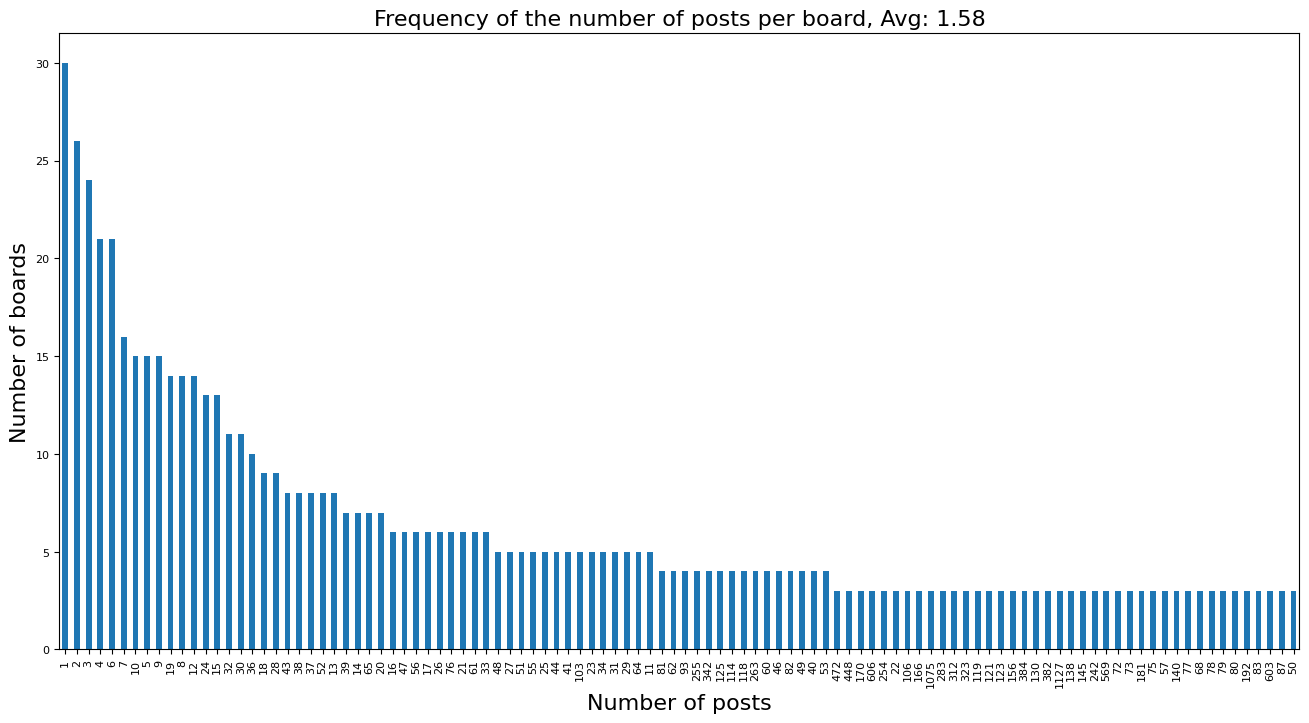

In [73]:
mean_val = round(post_board_df_.mean(), 2)

ax = post_board_df_.loc[:50].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of posts per board, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of posts", fontsize=16)
ax.set_ylabel("Number of boards", fontsize=16)

#### Posts x Threads

In [74]:
posts_threads_df = pd.merge(posts_boards_df, threads_df[["site_id", "board_id", "thread_id", "thread_title"]].drop_duplicates(), on=["site_id", "board_id", "thread_id"], how="left")
posts_threads_df

,post_id,site_id,board_id,thread_id,user_id,username,user_reputation,content,post_data_creation,site_name,board_title,thread_title
0,24355,3,19,5,22290,NaN,0,"thanks, for this great tutorial!",2015-12-25 09:56:00-02,offensivecommunity.net/index.php,Advanced Hacking Tutorials,Wireless Hacking {Cracking WEP key}
1,23917,3,19,5,22115,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-12-13 08:14:00-02,offensivecommunity.net/index.php,Advanced Hacking Tutorials,Wireless Hacking {Cracking WEP key}
2,12023,3,19,5,19519,NaN,0,***CITING***[http://offensivecommunity.net/pos...,2015-07-23 23:18:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials,Wireless Hacking {Cracking WEP key}
3,2,3,19,5,27,NaN,0,It's good to see such a valuable information o...,2012-06-30 08:49:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials,Wireless Hacking {Cracking WEP key}
4,8,3,19,5,26,NaN,0,Perfect one!!!\neasy to learn with such kind o...,2012-06-30 07:48:00-03,offensivecommunity.net/index.php,Advanced Hacking Tutorials,Wireless Hacking {Cracking WEP key}
...,...,...,...,...,...,...,...,...,...,...,...,...
54443382,59064545,0,32,6017249,2663062,Donald Trump Jr.,80,Get NordVpn or ProtonVpn Protonvpn definitely ...,2019-10-18 02:02:00-03,hackforums.net,"Movies, TV, and Videos",Movies / TV shows
54443383,59064520,0,32,6017249,1201566,Natas,1042,Nord is a good vpn u will be ight,2019-10-18 01:48:00-03,hackforums.net,"Movies, TV, and Videos",Movies / TV shows
54443384,59064512,0,32,6017249,4388154,Hoopinkid,8,I got a isp warning recently using popcorn tim...,2019-10-18 01:43:00-03,hackforums.net,"Movies, TV, and Videos",Movies / TV shows
54443385,59065236,0,32,6017325,4395338,Nsane Warez,0,anyone need a invite to the scene holla!!,2019-10-18 09:26:00-03,hackforums.net,"Movies, TV, and Videos",invite


In [75]:
post_thread_board_df = pd.pivot_table(posts_threads_df[["thread_title", "site_name", "thread_id", "post_id"]].drop_duplicates(),
                                 index=["site_name", "thread_title", "thread_id"],
                                 values=["post_id"],
                                 aggfunc={
                                     "post_id":len
                                 }
                                ).sort_values(by="post_id", ascending=False)#.reset_index(level=0)
post_thread_board_df.rename(columns={"post_id":"num_posts_created"}, inplace=True)
post_thread_board_df.reset_index(inplace=True)
post_thread_board_df.set_index(["thread_title", "site_name"], inplace=True)
post_thread_board_df.drop_duplicates(inplace=True)
post_thread_board_df.drop(columns=['thread_id'], inplace=True)
post_thread_board_df

,,num_posts_created
thread_title,site_name,
Ваши вопросы по уязвимостям.,forum.antichat.ru,24131
Расшифровка hash. Part1 (MD5),forum.antichat.ru,23577
[php] Новичкам: задаем вопросы,forum.antichat.ru,22424
Перебор и подбор пароля Wi-FI - WPA2 (2018),forum.antichat.ru,20322
"Расшифровка hash. Part3 (DES, MySQL, SHA-1, и прочие)",forum.antichat.ru,15977
...,...,...
Free webinar on Wordpress,hackforums.net,1
~ Download ~ Michael Jackson Thriller Leaked album Download,www.safeskyhacks.com/Forums/forum.php,1
~ Download ~ Lin-Manuel Miranda The Hamilton FULL ALBUM,www.safeskyhacks.com/Forums/forum.php,1


In [76]:
post_threads_board_df_ = post_thread_board_df.pivot_table(columns=['num_posts_created'], aggfunc='size')
post_threads_board_df_.sort_values(ascending=False, inplace=True)
post_threads_board_df_

num_posts_created
1       926261
3       527248
2       499517
4       416181
5       361567
         ...  
3373         1
3439         1
3551         1
8596         1
8386         1
Length: 1624, dtype: int64

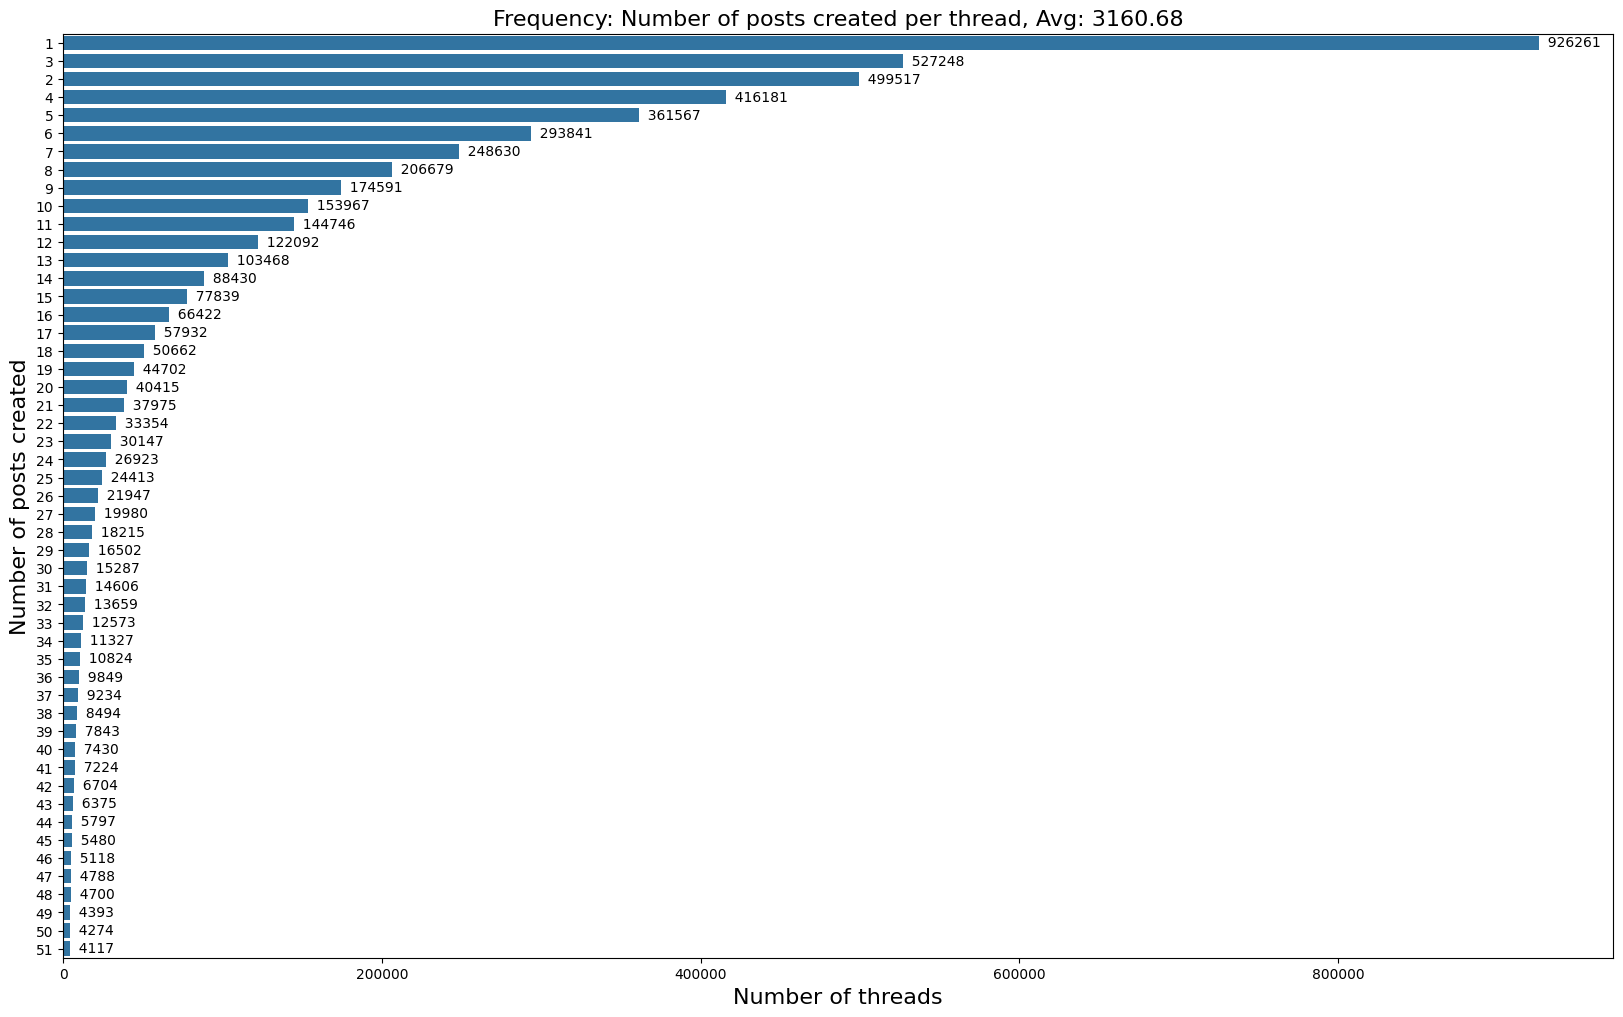

In [77]:
mean_val = round(post_threads_board_df_.mean(), 2)

_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

df = post_threads_board_df_.reset_index()

sns_fig = sns.barplot(
            data=df,
            x=df.columns[1],
            y=df.columns[0],
            orient="h",
            ax=ax,
            order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:50]
          )

sns_fig.set_title(f"Frequency: Number of posts created per thread, Avg: {mean_val}", fontsize=16)
sns_fig.set_xlabel("Number of threads", fontsize=16)
sns_fig.set_ylabel(f"Number of posts created", fontsize=16)
# sns_fig.set_yticks(range(0,95000,5000))

# # rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='  %0.0f', rotation=0)

Text(0, 0.5, 'Number of threads')

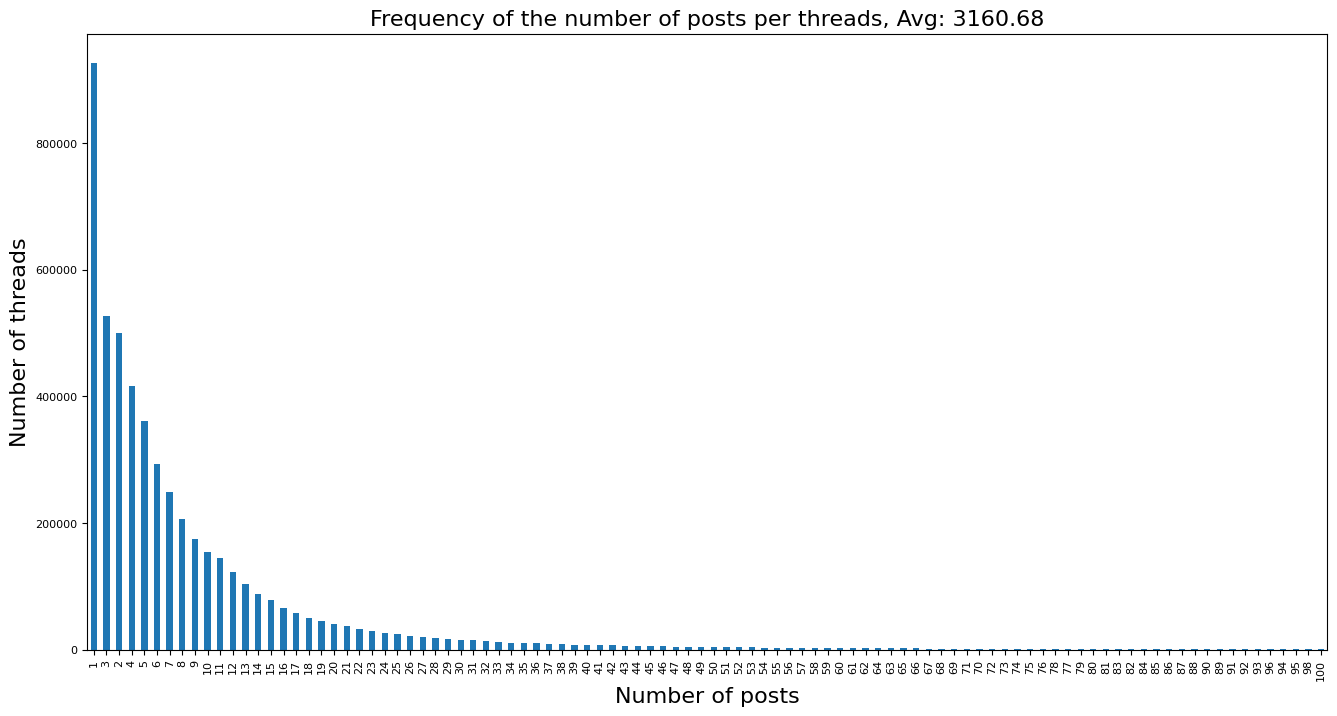

In [78]:
mean_val = round(post_threads_board_df_.mean(), 2)

ax = post_threads_board_df_.loc[:100].plot(kind="bar", figsize=(16,8), rot=90, fontsize=8)

#ax.get_legend().remove()
ax.set_title(f"Frequency of the number of posts per threads, Avg: {mean_val}", fontsize=16)
ax.set_xlabel("Number of posts", fontsize=16)
ax.set_ylabel("Number of threads", fontsize=16)